In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

c:\Users\User\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\User\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


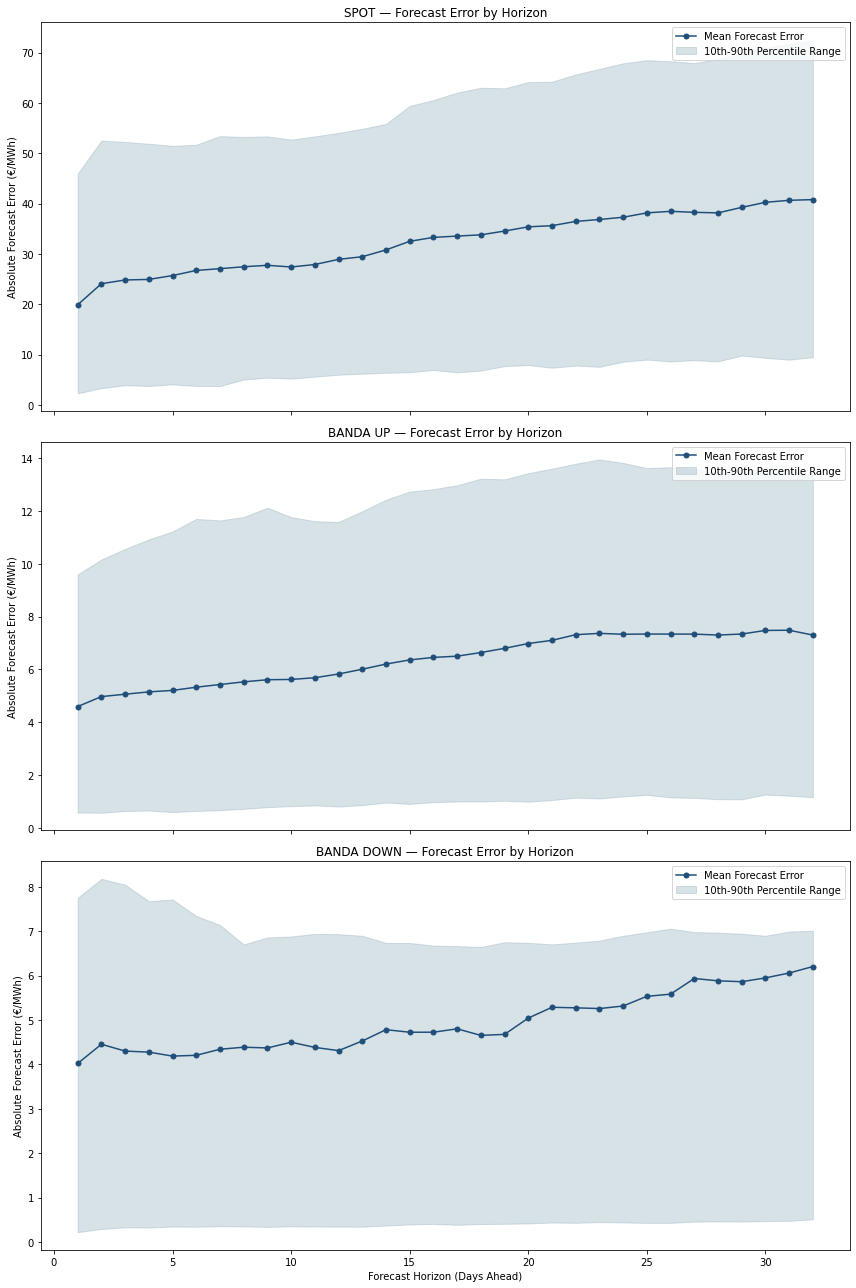

In [25]:

df = pd.read_csv('../data/backtesting_results/prediction_errors_horizon_32_days_SRS.csv')

categories = [
    ('SPOT_abs_error',         'SPOT'),
    ('BANDA_subir_abs_error',  'BANDA UP'),
    ('BANDA_bajar_abs_error',  'BANDA DOWN')
]

# Horizonte fijo de días que quieres mostrar
DAYS = np.arange(1, 33)  # 1 a 32

fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)

for ax, (err_col, title) in zip(axes, categories):

    # La columna de días asociada
    days_col = err_col.replace('_abs_error', '_days_since_start')

    # --- Calcular media por día, asegurando todos los días ---
    means = df.groupby(days_col)[err_col].mean()
    p10 = df.groupby(days_col)[err_col].quantile(0.1)
    p90 = df.groupby(days_col)[err_col].quantile(0.9)

    # --- Barras de error medio ---
    #ax.bar(DAYS, means.values, alpha=0.5, label="Mean error")

    # --- Línea de puntos en la media ---
    #ax.plot(DAYS, means.values, "o--", label="Mean", markersize=5)
    #ax.fill_between(DAYS, p10.values, p90.values, color='gray', alpha=0.3, label="10th-90th Percentile Range")
    # ax.errorbar(
    # DAYS,
    # means.values,
    # yerr=[means.values - p10.values, p90.values - means.values],
    # fmt="o",
    # capsize=3,
    # color="#7d9fb0",
    # ecolor="gray",
    # elinewidth=1,
    # label="Mean ± (P10–P90)"
    # )
    ax.fill_between(
        DAYS,
        p10.values,
        p90.values,
        color='#7d9fb0',
        alpha=0.3,
        label="10th-90th Percentile Range"
    )

    ax.plot(
        DAYS,
        means.values,
        "o-",
        color="#1f4e79",
        label="Mean Forecast Error",
        markersize=5
    )
    ax.set_title(f"{title} — Forecast Error by Horizon")
    ax.set_ylabel("Absolute Forecast Error (€/MWh)")
    ax.legend()

plt.xlabel("Forecast Horizon (Days Ahead)")
plt.tight_layout()
plt.savefig('../data/backtesting_results/images/prediction_errors_by_day_SRS.png')
plt.show()

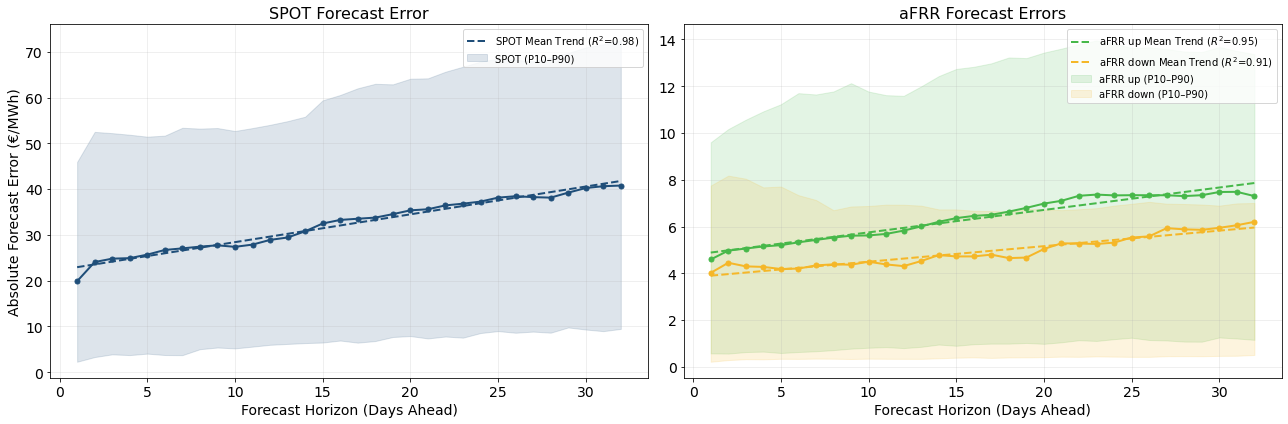

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# LOAD DATA
# ===============================
df = pd.read_csv(
    '../data/backtesting_results/prediction_errors_horizon_32_days_SRS.csv'
)

categories = [
    ("SPOT_abs_error",         "SPOT"),
    ("BANDA_subir_abs_error",  "aFRR up"),
    ("BANDA_bajar_abs_error",  "aFRR down"),
]

colors = {
    "SPOT":        "#1f4e79",
    "aFRR up":     "#47b84a",
    "aFRR down":   "#f5b728",
}

alpha_band = 0.15
DAYS = np.arange(1, 33)

# ===============================
# FIGURE (1x2)
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# ======================================================
# ============== LEFT PANEL: SPOT ======================
# ======================================================
ax = axes[0]

err_col, label = categories[0]
days_col = err_col.replace("_abs_error", "_days_since_start")

means = df.groupby(days_col)[err_col].mean().reindex(DAYS)
p10   = df.groupby(days_col)[err_col].quantile(0.10).reindex(DAYS)
p90   = df.groupby(days_col)[err_col].quantile(0.90).reindex(DAYS)

# P10–P90 band
ax.fill_between(
    DAYS, p10.values, p90.values,
    color=colors[label], alpha=alpha_band,
    label=f"{label} (P10–P90)"
)

# Mean
ax.plot(
    DAYS, means.values, "o-",
    color=colors[label],
    linewidth=2, markersize=5
)

# ---------- Linear regression ----------
mask = ~means.isna()
x = DAYS[mask]
y = means.values[mask]

coef = np.polyfit(x, y, 1)
trend = np.polyval(coef, DAYS)

# R^2
y_hat = np.polyval(coef, x)
ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

ax.plot(
    DAYS, trend, "--",
    color=colors[label],
    linewidth=2,
    label=f"{label} Mean Trend ($R^2$={r2:.2f})"
)

ax.set_title("SPOT Forecast Error", fontsize=16)
ax.set_xlabel("Forecast Horizon (Days Ahead)", fontsize=14)
ax.set_ylabel("Absolute Forecast Error (€/MWh)", fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)
ax.grid(alpha=0.25)
ax.legend()

# ======================================================
# ============== RIGHT PANEL: aFRR =====================
# ======================================================
ax = axes[1]

for err_col, label in categories[1:]:

    days_col = err_col.replace("_abs_error", "_days_since_start")

    means = df.groupby(days_col)[err_col].mean().reindex(DAYS)
    p10   = df.groupby(days_col)[err_col].quantile(0.10).reindex(DAYS)
    p90   = df.groupby(days_col)[err_col].quantile(0.90).reindex(DAYS)

    # P10–P90 band
    ax.fill_between(
        DAYS, p10.values, p90.values,
        color=colors[label], alpha=alpha_band,
        label=f"{label} (P10–P90)"
    )

    # Mean
    ax.plot(
        DAYS, means.values, "o-",
        color=colors[label],
        linewidth=2, markersize=5
    )

    # ---------- Linear regression ----------
    mask = ~means.isna()
    x = DAYS[mask]
    y = means.values[mask]

    coef = np.polyfit(x, y, 1)
    trend = np.polyval(coef, DAYS)

    # R^2
    y_hat = np.polyval(coef, x)
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    ax.plot(
        DAYS, trend, "--",
        color=colors[label],
        linewidth=2,
        label=f"{label} Mean Trend ($R^2$={r2:.2f})"
    )

ax.set_title("aFRR Forecast Errors", fontsize=16)
ax.set_xlabel("Forecast Horizon (Days Ahead)", fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.savefig(
    '../data/backtesting_results/images/prediction_errors_SPOT_vs_aFRR_SRS.pdf',
    dpi=300
)
plt.show()




C:\Users\User\AppData\Local\Temp/ipykernel_22428/1078774617.py:6: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["datetime"] = pd.to_datetime(df["datetime"])


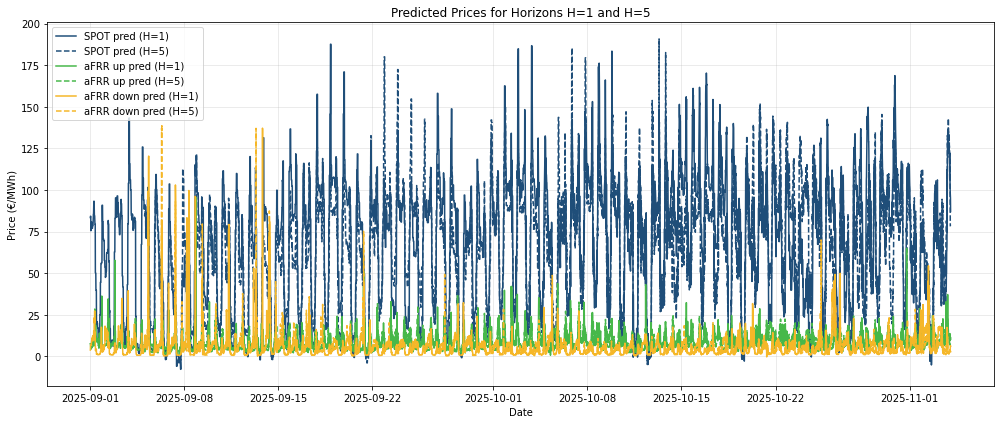

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv('../data/backtesting_results/prediction_errors_horizon_32_days_SRS.csv')
df["datetime"] = pd.to_datetime(df["datetime"])

# Colores solicitados
colors = {
    "SPOT":      "#1f4e79",
    "aFRR up":   "#47b84a",
    "aFRR down": "#f5b728",
}

# Horizontes a mostrar
H1 = 1
H5 = 5

# Filtrado por horizonte
spot_h1  = df[df["SPOT_days_since_start"] == H1]
spot_h5  = df[df["SPOT_days_since_start"] == H5]

up_h1    = df[df["BANDA_subir_days_since_start"] == H1]
up_h5    = df[df["BANDA_subir_days_since_start"] == H5]

down_h1  = df[df["BANDA_bajar_days_since_start"] == H1]
down_h5  = df[df["BANDA_bajar_days_since_start"] == H5]

# Plot
plt.figure(figsize=(14, 6))

# SPOT
plt.plot(spot_h1["datetime"].values, spot_h1["SPOT_pred"].values, 
         label="SPOT pred (H=1)", 
         color=colors["SPOT"], linestyle="-")

plt.plot(spot_h5["datetime"].values, spot_h5["SPOT_pred"].values, 
         label="SPOT pred (H=5)", 
         color=colors["SPOT"], linestyle="--")

# aFRR up
plt.plot(up_h1["datetime"].values, up_h1["BANDA_subir_pred"].values, 
         label="aFRR up pred (H=1)", 
         color=colors["aFRR up"], linestyle="-")

plt.plot(up_h5["datetime"].values, up_h5["BANDA_subir_pred"].values, 
         label="aFRR up pred (H=5)", 
         color=colors["aFRR up"], linestyle="--")

# aFRR down
plt.plot(down_h1["datetime"].values, down_h1["BANDA_bajar_pred"].values, 
         label="aFRR down pred (H=1)", 
         color=colors["aFRR down"], linestyle="-")

plt.plot(down_h5["datetime"].values, down_h5["BANDA_bajar_pred"].values, 
         label="aFRR down pred (H=5)", 
         color=colors["aFRR down"], linestyle="--")

plt.xlabel("Date")
plt.ylabel("Price (€/MWh)")
plt.title("Predicted Prices for Horizons H=1 and H=5")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp/ipykernel_384/3268209973.py:7: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["datetime"] = pd.to_datetime(df["datetime"])


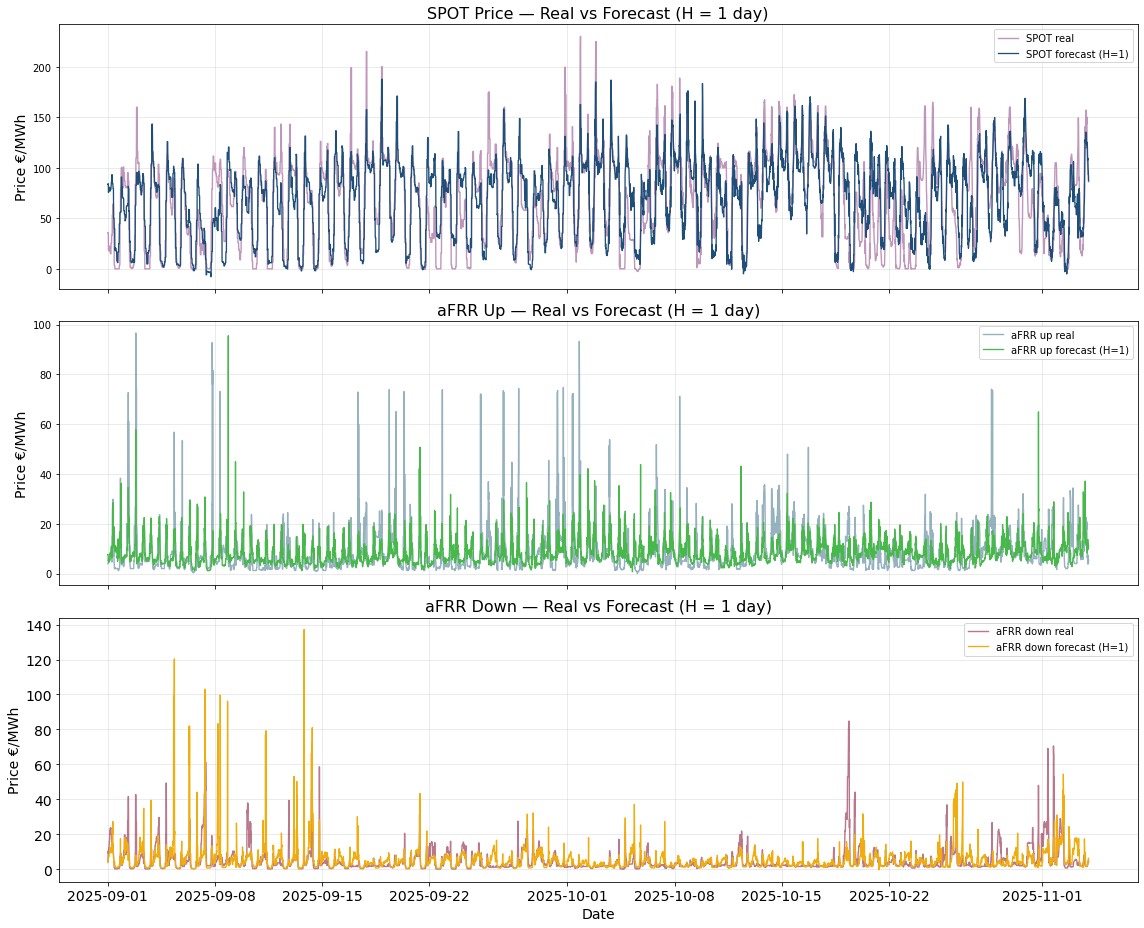

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv('../data/backtesting_results/prediction_errors_horizon_32_days_SRS.csv')

df["datetime"] = pd.to_datetime(df["datetime"])
PALETTE = ["#1f4e79","#7d9fb0","#a6d8a8", "#f2c14e"]

#palette = ["#1f4e79", "#f1ad0e", "plum", "#47b84a"]
# Colores solicitados
colors = {
    "SPOT":      "#1f4e79",
    "aFRR up":   "#47b84a",
    "aFRR down": "#f1ad0e",
}

# Horizonte a mostrar
H1 = 1

# Filtrado por horizonte 1
spot_h1  = df[df["SPOT_days_since_start"] == H1]
up_h1    = df[df["BANDA_subir_days_since_start"] == H1]
down_h1  = df[df["BANDA_bajar_days_since_start"] == H1]

# Crear figura con 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(16,13), sharex=True)

# --- 1) SPOT ---


axes[0].plot(spot_h1["datetime"].values, spot_h1["SPOT_real"].values, 
             label="SPOT real",
             color="#b07da9", linewidth=1.4, alpha=0.8)
axes[0].plot(spot_h1["datetime"].values, spot_h1["SPOT_pred"].values,
             label="SPOT forecast (H=1)",
             color=colors["SPOT"], linewidth=1.3)

axes[0].set_ylabel("Price €/MWh", size=14)
axes[0].set_title("SPOT Price — Real vs Forecast (H = 1 day)", size=16)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# --- 2) aFRR UP ---

axes[1].plot(up_h1["datetime"].values, up_h1["BANDA_subir_real"].values,
             label="aFRR up real",
             color="#7d9fb0", linewidth=1.4, alpha=0.8)
axes[1].plot(up_h1["datetime"].values, up_h1["BANDA_subir_pred"].values,
             label="aFRR up forecast (H=1)",
             color=colors["aFRR up"], linewidth=1.3)


axes[1].set_ylabel("Price €/MWh", size=14)
axes[1].set_title("aFRR Up — Real vs Forecast (H = 1 day)", size=16)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# --- 3) aFRR DOWN ---
filtro = down_h1['BANDA_bajar_real'] < 350

axes[2].plot(
    down_h1.loc[filtro, "datetime"].values,
    down_h1.loc[filtro, "BANDA_bajar_real"].values,
    label="aFRR down real", color="#8b1e3f", linewidth=1.4, alpha=0.6
)
axes[2].plot(down_h1["datetime"].values, down_h1["BANDA_bajar_pred"].values,
             label="aFRR down forecast (H=1)",
             color=colors["aFRR down"], linewidth=1.3)


axes[2].set_ylabel("Price €/MWh", size=14)
axes[2].set_title("aFRR Down — Real vs Forecast (H = 1 day)", size=16)
axes[2].tick_params(axis='x', labelsize=14)
axes[2].tick_params(axis='y', labelsize=14)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

axes[2].set_xlabel("Date", size=14)
plt.tight_layout()
plt.savefig('../data/backtesting_results/images/price_comparison_horizon_1_SRS.pdf', dpi=300)
plt.show()


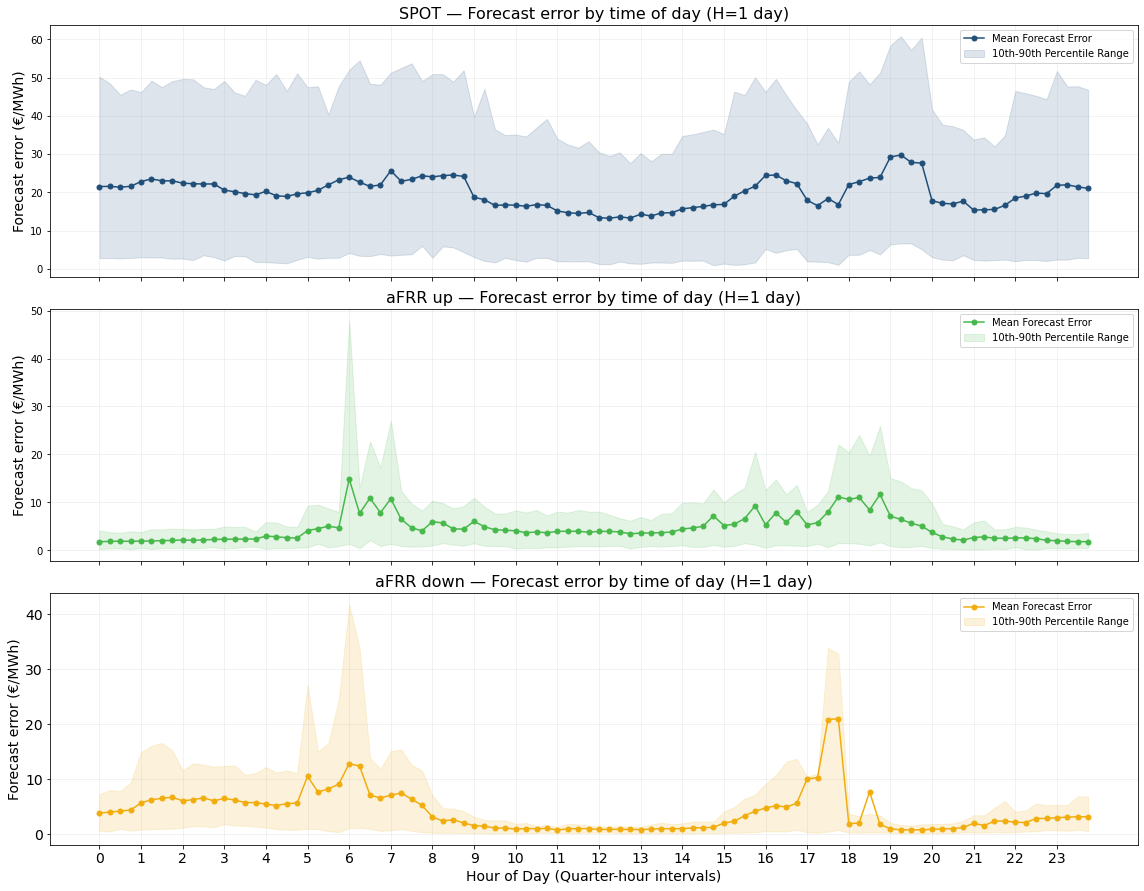

In [58]:
# --- Cargar datos ---
df = pd.read_csv('../data/backtesting_results/prediction_errors_horizon_32_days_SRS.csv')
df["datetime"] = df["datetime"].astype(str)
# Asegurar que datetime es datetime real
df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")

# Calcular quarter-of-day (0–95) una sola vez
df['quarter'] = df['datetime'].dt.hour * 4 + df['datetime'].dt.minute // 15

df = df[df['SPOT_days_since_start'] == 1]  # Filtrar horizonte = 1 día

# Mapeo: nombre lógico → (columna de error, columna de days_since_start)
cols = {
    "SPOT":       ("SPOT_abs_error",        "SPOT_days_since_start"),
    "aFRR up":   ("BANDA_subir_abs_error", "BANDA_subir_days_since_start"),
    "aFRR down": ("BANDA_bajar_abs_error", "BANDA_bajar_days_since_start"),
}

colors = {
    "SPOT":        "#1f4e79",
    "aFRR up":     "#47b84a",
    "aFRR down":   "#f1ad0e",
}

alpha_band = 0.15

# --- Crear figura 3x1 ---
fig, axs = plt.subplots(3, 1, figsize=(16,13), sharex=True)
#fig.suptitle("Forecast error by time of day", fontsize=16)

for i, (name, (err_col, day_col)) in enumerate(cols.items()):
    ax = axs[i]

    # Agrupar por cuarto de hora
    grouped = df.groupby('quarter')[err_col]

    means = grouped.mean()
    p10   = grouped.quantile(0.10)
    p90   = grouped.quantile(0.90)

    # Eje X = quarters disponibles (0–95)
    x = means.index.values

    # --- Errorbar: media ± (P10–P90) ---
    ax.fill_between(
        x,
        p10.values,
        p90.values,
        color = colors[name],
        alpha=alpha_band,
        label="10th-90th Percentile Range"
    )

    ax.plot(
        x,
        means.values,
        "o-",
        color=colors[name],
        label="Mean Forecast Error",
        markersize=5
    )

    # Formato del subplot
    ax.set_title(f"{name} — Forecast error by time of day (H=1 day)", fontsize=16)
    ax.set_ylabel("Forecast error (€/MWh)", fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.2)

# Etiqueta común de X
axs[-1].set_xlabel("Hour of Day (Quarter-hour intervals)", fontsize=14)
hour_ticks = np.arange(0, 96, 4)
hour_labels = [f"{h}" for h in range(24)]
plt.xticks(hour_ticks, hour_labels)

plt.tick_params(axis='y', labelsize=14)
plt.tick_params(axis='x', labelsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # para que no pise el suptitle
plt.savefig('../data/backtesting_results/images/forecast_error_by_time_of_day.pdf', dpi=300)
plt.show()



In [26]:
import pandas as pd
import glob
import re

def load_strategy(strategy):
    """
    Carga todos los ficheros revenues_strategies_horizon_X_{strategy}.csv
    y devuelve un único dataframe concatenado.
    """
    path = "../data/backtesting_results/files_revenues/merged_files/"
    files = glob.glob(path + f"revenues_per_day_strategies_horizon_*_{strategy}.csv")

    dfs = []

    for f in files:
        df = pd.read_csv(f)

        # Asegurar que el día sea fecha
        df['day'] = pd.to_datetime(df['day']).dt.date

        # Extraer el horizonte desde el nombre del fichero
        m = re.search(r"horizon_(\d+)_", f)
        if m:
            df["Horizon"] = int(m.group(1))

        # Etiquetar estrategia
        df["Model"] = strategy

        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


def plot_comparison_superposed(df):
    df = df.copy()
    df['day'] = pd.to_datetime(df['day']).dt.date

    horizons = sorted(df["Horizon"].unique())
    strategies = sorted(df["Model"].unique())  # Baseline, SRS

    # Colores principales para las líneas de los modelos
    line_colors = {
        "baseline": "black",
        "SRS": "blue"
    }

    # Colores más claros para las líneas de la mediana
    median_colors = {
        "baseline": "gray",
        "SRS": "#77aaff"   # azul clarito
    }

    # Colores de texto para que resalten
    text_colors = {
        "baseline": "indigo",
        "SRS": "midnightblue"
    }

    fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=False)
    fig.suptitle("Ex-ante / Ex-post (%) — Baseline vs SRS", fontsize=18)

    for ax, horizon in zip(axes.flatten(), horizons):

        d = df[df["Horizon"] == horizon]

        for model in strategies:

            # Colores particulares según modelo
            color = line_colors.get(model, "black")
            med_color = median_colors.get(model, "lightgray")
            text_color = text_colors.get(model, "black")

            d_model = d[d["Model"] == model]

            d1 = d_model[d_model["Strategy"] == "Ex-post"].sort_values("day")
            d2 = d_model[d_model["Strategy"] == "perfect_foresight"].sort_values("day")

            merged = pd.merge(
                d1[["day", "net_profit_EUR"]],
                d2[["day", "net_profit_EUR"]],
                on="day",
                suffixes=("_Exante", "_Expost")
            )

            merged["pct"] = 100 * merged["net_profit_EUR_Exante"] / merged["net_profit_EUR_Expost"]

            # Línea temporal diaria
            ax.plot(
                merged["day"].values,
                merged["pct"].values,
                marker="o",
                color=color
            )

            # Línea de mediana (más clara)
            med = merged["pct"].mean()
            ax.axhline(
                med,
                linestyle="--",
                color=med_color,
                label=f"{med:.1f}%",
                alpha=0.9
            )

            # Texto por encima de la línea
            # ax.text(
            #     merged["day"].min(),
            #     med + 0.5,              # desplazamiento vertical
            #     f"{med:.1f}%",
            #     color=text_color,
            #     fontsize=10,
            #     fontweight="bold"
            # )

        ax.set_title(f"Horizon {horizon}")
        ax.set_xlabel("Date")
        ax.set_ylabel("Percentage (%)")
        ax.grid(True)
        ax.legend()
        ax.tick_params(axis='x', rotation=45)

    # Leyenda global
    handles = [
        plt.Line2D([0], [0], color=line_colors["SRS"], label="SRS"),
        plt.Line2D([0], [0], color=line_colors["baseline"], label="Baseline"),        
    ]
    fig.legend(handles=handles, loc="upper right", fontsize=12)

    fig.tight_layout(rect=[0, 0, 0.95, 0.95])
    plt.show()


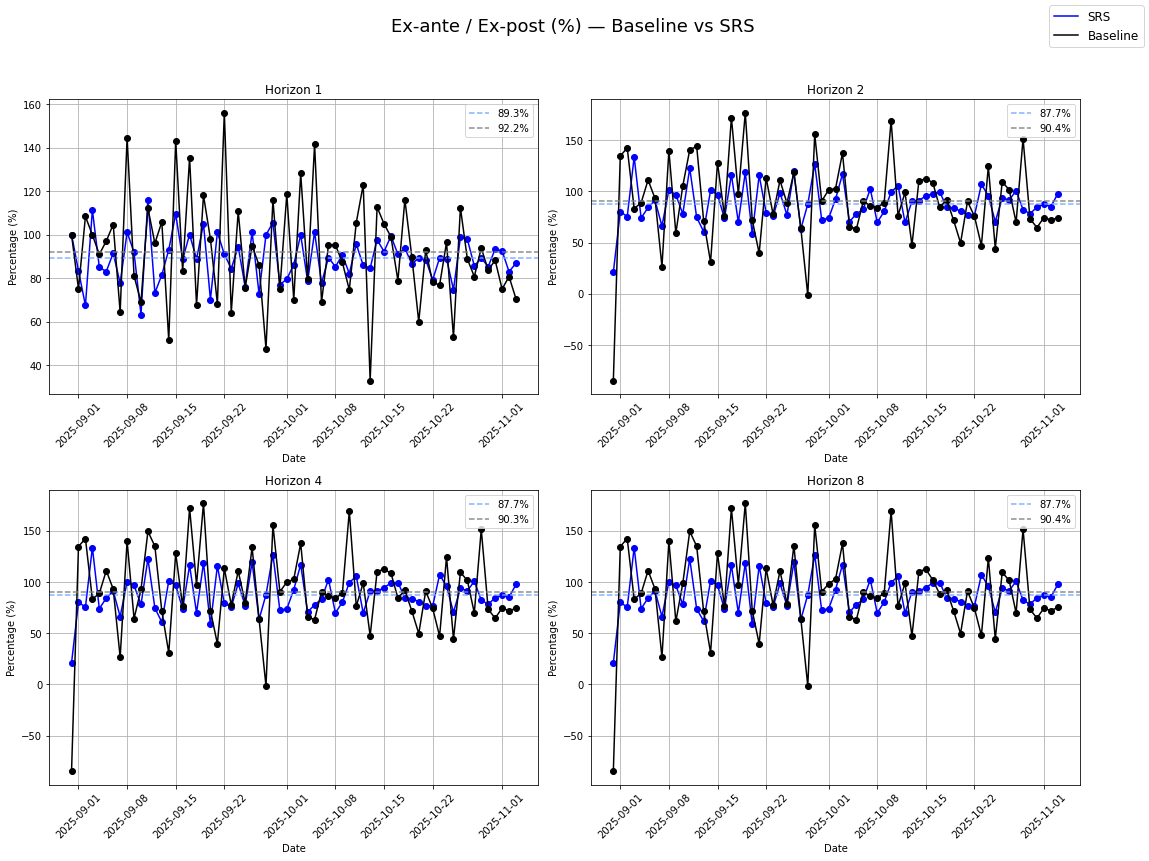

In [27]:
df_baseline = load_strategy("baseline")
df_srs = load_strategy("SRS")

df_all = pd.concat([df_baseline, df_srs], ignore_index=True)

plot_comparison_superposed(df_all)



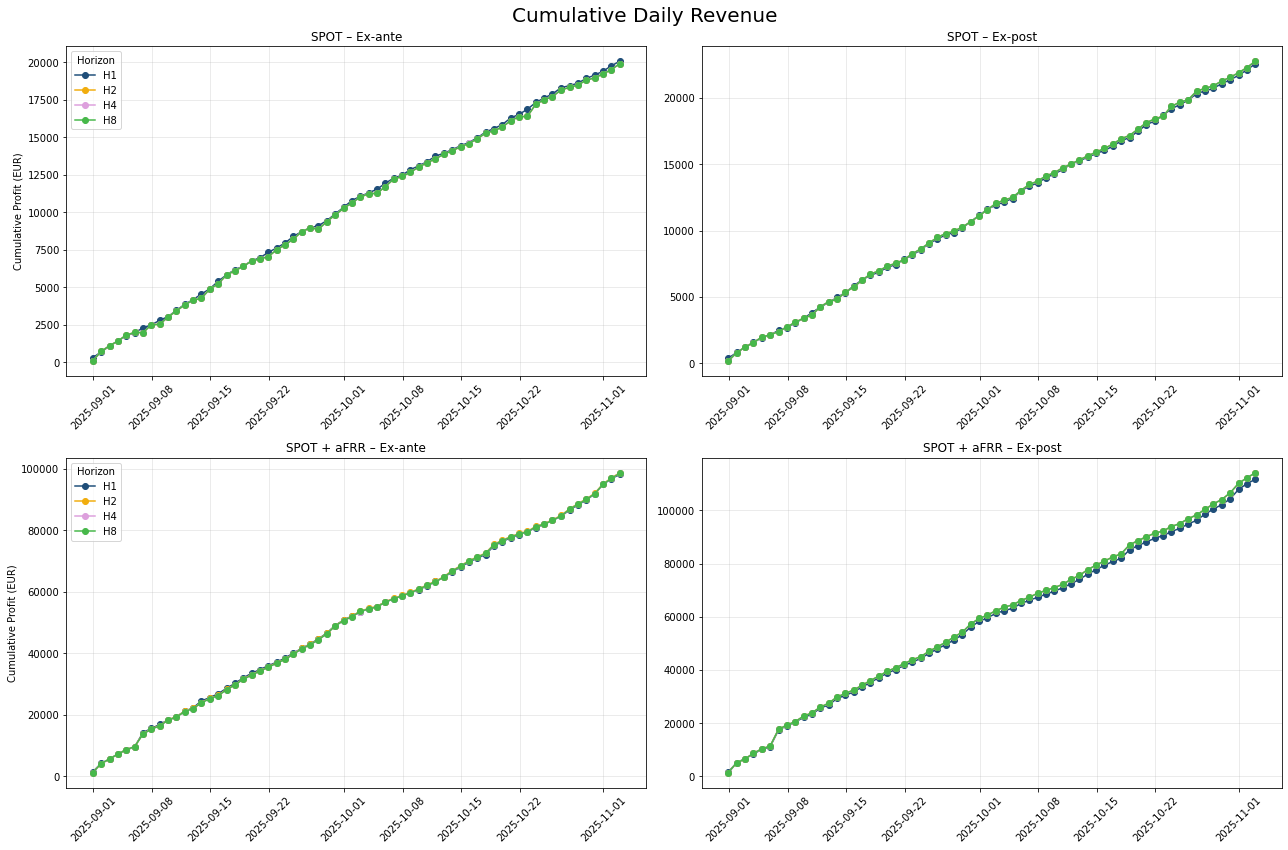

In [38]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import re

def load_strategy(strategy):
    """
    Carga todos los ficheros revenues_strategies_horizon_X_{strategy}.csv
    y devuelve un único dataframe concatenado.
    """
    path = "../data/backtesting_results/files_revenues_qh_cycled/merged_files_cycled/"
    files = glob.glob(path + f"revenues_qh_strategies_horizon_*_{strategy}.csv")

    dfs = []

    for f in files:
        df = pd.read_csv(f)
        df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
        df['datetime'] = df['datetime'].dt.tz_convert('Europe/Madrid')
        df['day'] = df['datetime'].dt.normalize()

        df_grouped = df.groupby(['day', 'Strategy'])['net_profit_EUR'].sum().reset_index()

        # Extraer el horizonte desde el nombre del fichero
        m = re.search(r"horizon_(\d+)_", f)
        if m:
            df_grouped["Horizon"] = int(m.group(1))

        # Etiquetar estrategia
        df_grouped["Model"] = strategy

        dfs.append(df_grouped)

    return pd.concat(dfs, ignore_index=True)

# ===============================
# Configuración de colores
# ===============================
palette = ["#1f4e79", "#f1ad0e", "plum", "#47b84a"]

# Renombrar modelos para mostrarlos en la gráfica
model_label = {
    "baseline": "SPOT",
    "SRS": "SPOT + aFRR"
}

# ===============================
# Función genérica para calcular curvas acumuladas
# ===============================
def compute_cumulative(df):
    df = df.copy()
    #df["day"] = pd.to_datetime(df["day"]).dt.date

    out = {}
    for strategy, df_s in df.groupby("Strategy"):  # Ex-post / perfect_foresight
        curves = {}
        for horizon, data in df_s.groupby("Horizon"):
            if horizon in [16, 32]:
                continue
            d = data.sort_values("day")
            d["cum_profit"] = d["net_profit_EUR"].cumsum()
            curves[horizon] = d
        out[strategy] = curves
    return out

# ===============================
# Cargar ambos modelos
# ===============================
df_baseline = load_strategy("baseline")   # SPOT
df_SRS = load_strategy("SRS")             # SPOT+aFRR

curves_baseline = compute_cumulative(df_baseline)
curves_SRS = compute_cumulative(df_SRS)

# ===============================
# CREAR FIGURA 2×2
# ===============================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
(ax00, ax01), (ax10, ax11) = axes

# ------------------------------------------
# Baseline (SPOT) – Ex-ante → panel (0,0)
# ------------------------------------------
for i, (h, d) in enumerate(curves_baseline["Ex-post"].items()):
    ax00.plot(d["day"].values, d["cum_profit"].values, marker="o",
              color=palette[i % len(palette)], label=f"H{h}")
ax00.set_title("SPOT – Ex-ante")
ax00.grid(alpha=0.3)
ax00.tick_params(axis="x", rotation=45)
ax00.set_ylabel("Cumulative Profit (EUR)")
ax00.legend(title="Horizon")

# ------------------------------------------
# Baseline (SPOT) – Ex-post → panel (0,1)
# ------------------------------------------
for i, (h, d) in enumerate(curves_baseline["perfect_foresight"].items()):
    ax01.plot(d["day"].values, d["cum_profit"].values, marker="o",
              color=palette[i % len(palette)], label=f"H{h}")
ax01.set_title("SPOT – Ex-post")
ax01.grid(alpha=0.3)
ax01.tick_params(axis="x", rotation=45)

# ------------------------------------------
# SRS (SPOT+aFRR) – Ex-ante → panel (1,0)
# ------------------------------------------
for i, (h, d) in enumerate(curves_SRS["Ex-post"].items()):
    ax10.plot(d["day"].values, d["cum_profit"].values, marker="o",
              color=palette[i % len(palette)], label=f"H{h}")
ax10.set_title("SPOT + aFRR – Ex-ante")
ax10.grid(alpha=0.3)
ax10.tick_params(axis="x", rotation=45)
ax10.set_ylabel("Cumulative Profit (EUR)")
ax10.legend(title="Horizon")

# ------------------------------------------
# SRS (SPOT+aFRR) – Ex-post → panel (1,1)
# ------------------------------------------
for i, (h, d) in enumerate(curves_SRS["perfect_foresight"].items()):
    ax11.plot(d["day"].values, d["cum_profit"].values, marker="o",
              color=palette[i % len(palette)], label=f"H{h}")
ax11.set_title("SPOT + aFRR – Ex-post")
ax11.grid(alpha=0.3)
ax11.tick_params(axis="x", rotation=45)

plt.suptitle("Cumulative Daily Revenue", fontsize=20)
plt.tight_layout()
plt.savefig('../data/backtesting_results/images/cumulative_revenue_subplot.pdf')
plt.show()

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# df_net_global_profit contiene: day, net_profit_EUR, Strategy, Horizon

def plot_comparisons(df):
    horizons = sorted(df["Horizon"].unique())

    pairs = [
        ("Ex-ante", "Ex-post"),
        ("Ex-ante", "Perfect Foresight"),
        ("Ex-post", "Perfect Foresight"),
    ]
    titles = [
        "Ex-ante vs Ex-post",
        "Ex-ante vs Perfect Foresight",
        "Ex-post vs Perfect Foresight",
    ]

    for (s1, s2), title in zip(pairs, titles):

        fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=False)
        fig.suptitle(title, fontsize=18)

        for ax, horizon in zip(axes.flatten(), horizons):

            d = df[df["Horizon"] == horizon]

            d1 = d[d["Strategy"] == s1].sort_values("day")
            d2 = d[d["Strategy"] == s2].sort_values("day")

            days = range(len(d1))

            # --- LINEA DE LOS VALORES POR DÍA ---
            ax.plot(days, d1["net_profit_EUR"], marker="o", label=s1)
            ax.plot(days, d2["net_profit_EUR"], marker="o", label=s2)

            # --- BOXPLOTS POR DÍA ---
            # Agrupamos por día para tener distribución diaria
            d1_daily = d1.groupby("day")["net_profit_EUR"].apply(list)
            d2_daily = d2.groupby("day")["net_profit_EUR"].apply(list)

            # Boxplots uno al lado del otro
            positions_1 = [x - 0.15 for x in days]
            positions_2 = [x + 0.15 for x in days]

            ax.boxplot(
                d1_daily.tolist(),
                positions=positions_1,
                widths=0.25,
                manage_ticks=False
            )
            ax.boxplot(
                d2_daily.tolist(),
                positions=positions_2,
                widths=0.25,
                manage_ticks=False
            )

            # --- LÍNEA DE PUNTOS DE LA MEDIA GLOBAL ---
            mean1 = d1["net_profit_EUR"].mean()
            mean2 = d2["net_profit_EUR"].mean()

            ax.scatter(days, [mean1]*len(days), marker="x", s=60, label=f"Media {s1}")
            ax.scatter(days, [mean2]*len(days), marker="x", s=60, label=f"Media {s2}")

            ax.set_title(f"Horizon {horizon}")
            ax.set_xlabel("Day index")
            ax.set_ylabel("Net Profit EUR")
            ax.grid(True)

        handles, labels = axes[0][0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper right", fontsize=12)
        fig.tight_layout(rect=[0, 0, 0.95, 0.95])
        plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_profit_heatmaps_qh_by_date(df):
    """
    Genera 3 heatmaps (96 x N_días) a partir de un df con columnas:
    - datetime
    - net_profit_EUR
    - Strategy (Ex-ante, Ex-post, perfect_foresight)
    
    Heatmaps:
      1) Profit ex-ante
      2) Profit ex-post
      3) Ratio ex-ante / ex-post (%)
    """

    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
    df['datetime'] = df['datetime'].dt.tz_convert('Europe/Madrid')

    # Día de calendario y cuarto de hora
    df['day'] = df['datetime'].dt.normalize()
    df["quarter"] = df["datetime"].dt.hour * 4 + df["datetime"].dt.minute // 15

    # Días únicos en orden cronológico (deberían ser 32)
    unique_days = sorted(df["day"].unique())
    all_quarters = np.arange(0, 96)  # 0..95

    def build_matrix(sub_df):
        """
        Devuelve matriz 96 x N_días con el profit sumado por quarter x día.
        """
        pivot = sub_df.pivot_table(
            index="quarter",
            columns="day",
            values="net_profit_EUR",
            aggfunc="sum"
        )

        pivot = pivot.reindex(index=all_quarters, columns=unique_days)
        return pivot.values

    # Filtrar estrategias
    df_exante = df[df["Strategy"] == "Ex-post"]
    df_expost = df[df["Strategy"] == "perfect_foresight"]

    mat_exante = build_matrix(df_exante)
    mat_expost = build_matrix(df_expost)

    # Ratio Ex-ante / Ex-post (%)
    ratio = np.where(mat_expost != 0, 100 * mat_exante / mat_expost, np.nan)

    # ---- Plot ----
    n_days = len(unique_days)
    fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)

    vmin = np.nanmin([mat_exante, mat_expost])
    vmax = np.nanmax([mat_exante, mat_expost])

    # 1) Ex-ante
    im0 = axes[0].imshow(mat_exante, aspect="auto", origin="lower",
                         vmin=vmin, vmax=vmax*0.6)
    axes[0].set_title("Ex-ante profit (EUR)")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # 2) Ex-post
    im1 = axes[1].imshow(mat_expost, aspect="auto", origin="lower",
                         vmin=vmin, vmax=vmax*0.6)
    axes[1].set_title("Ex-post profit (EUR)")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # 3) Ratio (%)
    im2 = axes[2].imshow(ratio, aspect="auto", origin="lower", cmap="coolwarm", vmax=ratio.max()*0.05)
    axes[2].set_title("Ex-ante / Ex-post (%)")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    # Eje X: días (usamos índices 0..N-1 y etiquetas con la fecha)
    x_positions = np.arange(n_days)
    day_labels = [d.strftime("%d-%m") for d in pd.to_datetime(unique_days)]

    for ax in axes:
        ax.set_xlabel("Day")
        ax.set_xticks(x_positions[::2])          # por ejemplo, una etiqueta cada 2 días
        ax.set_xticklabels(day_labels[::2], rotation=45)

    # Eje Y: quarters → etiquetamos como horas
    axes[0].set_ylabel("Quarter of day")
    y_positions = np.arange(0, 96, 8)           # cada 2 horas
    hour_labels = [f"{h:02d}:00" for h in range(0, 24, 2)]
    axes[0].set_yticks(y_positions)
    axes[0].set_yticklabels(hour_labels)

    plt.tight_layout()
    plt.show()


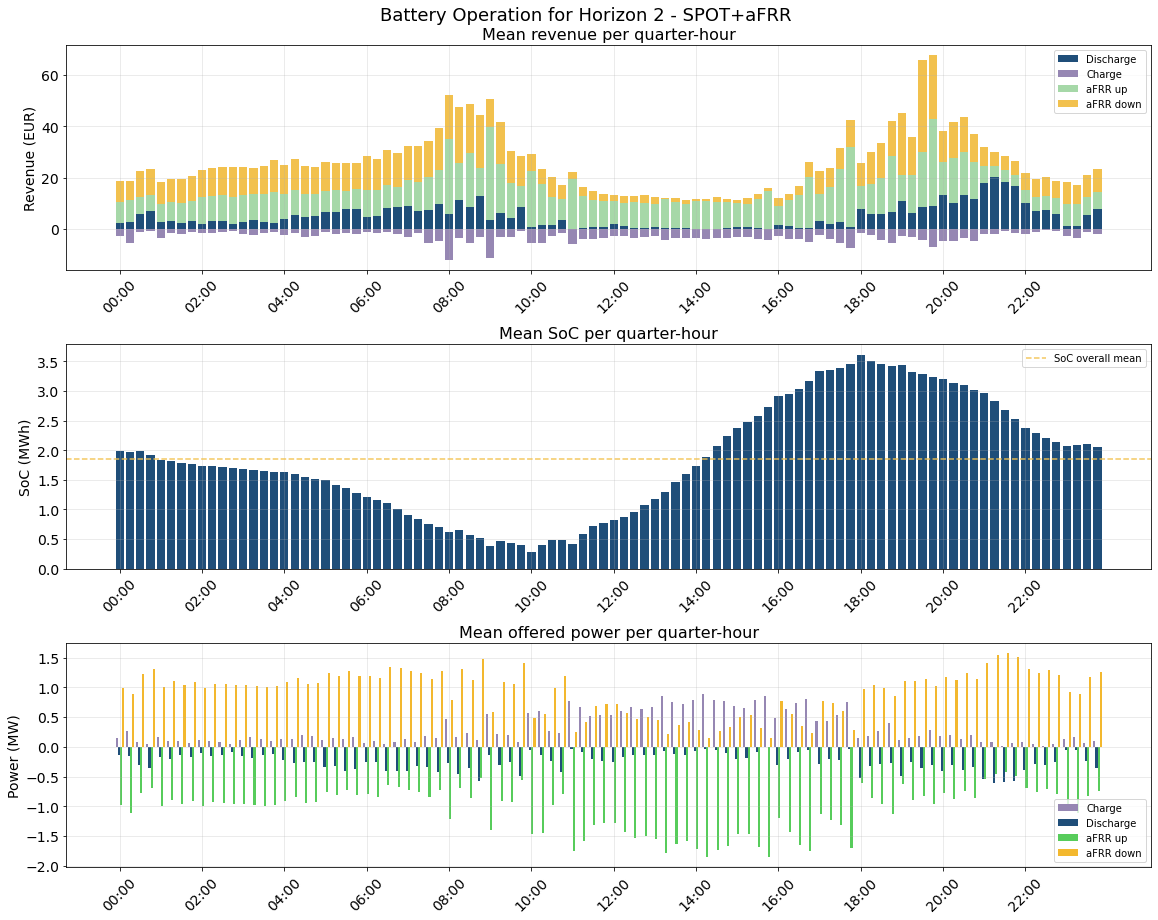

In [7]:

def plot_revenue_and_power(df):

    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
    df['datetime'] = df['datetime'].dt.tz_convert('Europe/Madrid')

    # ---------------------------
    # 1. Quarter-of-day
    # ---------------------------
    df["quarter"] = df["datetime"].dt.hour * 4 + df["datetime"].dt.minute // 15

    # ---------------------------
    # 2. Crear columnas de revenue desglosado
    # ---------------------------
    df["spot_charge_rev"] = np.where(df["charge_base_MW"] > 0, df["spot_revenue_EUR"], 0)
    df["spot_discharge_rev"] = np.where(df["discharge_base_MW"] > 0, df["spot_revenue_EUR"], 0)

    if "banda_up_offered_MW" in df.columns:
        df["banda_up_rev"] = np.where(df["banda_up_offered_MW"] > 0, df["banda_revenue_EUR"], 0)
        df["banda_down_rev"] = np.where(df["banda_down_offered_MW"] > 0, df["banda_revenue_EUR"], 0)
    else:
        df["banda_up_rev"] = 0
        df["banda_down_rev"] = 0

    # ---------------------------
    # 3. Agrupar por QH
    # ---------------------------
    group_cols = ["spot_discharge_rev", "spot_charge_rev", "charge_base_MW", "discharge_base_MW", "soc_start_MWh"]
    if "banda_up_offered_MW" in df.columns:
        group_cols.extend(["banda_up_offered_MW", "banda_down_offered_MW",  "banda_up_rev", "banda_down_rev"])
    grouped = df.groupby("quarter")[group_cols].mean()

    # ---------------------------
    # 4. Preparar eje X
    # ---------------------------
    qh = np.arange(96)
    time_labels = [(pd.Timestamp("2000-01-01") + pd.Timedelta(minutes=15*q)).strftime("%H:%M")
                   for q in qh]

    # ===========================
    # FIGURA (a) — REVENUES
    # ===========================
    # fig, ax = plt.subplots(2, 1, figsize=(16, 10))

    # ax0 = ax[0]

    # ax0.bar(qh, grouped["spot_discharge_rev"], color="#1f4e79", label="Discharge")
    # ax0.bar(qh, grouped["spot_charge_rev"], bottom=grouped["spot_discharge_rev"],
    #         color="#7d9fb0", label="Charge")
    # ax0.bar(qh, grouped["banda_up_rev"],
    #         bottom=grouped["spot_discharge_rev"] + grouped["spot_charge_rev"],
    #         color="#a6d8a8", label="aFRR up")
    # ax0.bar(qh, grouped["banda_down_rev"],
    #         bottom=grouped["spot_discharge_rev"] + grouped["spot_charge_rev"] + grouped["banda_up_rev"],
    #         color="#f2c14e", label="aFRR down")

    # ax0.set_title("Mean revenue per quarter-hour")
    # ax0.set_ylabel("Revenue (EUR)")
    # ax0.set_xticks(np.arange(0, 96, 8))
    # ax0.set_xticklabels(time_labels[::8], rotation=45)
    # ax0.legend()
    # ax0.grid(alpha=0.3)

    fig, ax = plt.subplots(3, 1, figsize=(16, 13))

    ax0 = ax[0]

    # Lista de columnas y estilos
    components = [
        ("spot_discharge_rev", "#1f4e79", "Discharge"),
        ("spot_charge_rev",    "#9687b3" , "Charge"),
        ("banda_up_rev",       "#a6d8a8", "aFRR up"),
        ("banda_down_rev",     "#f2c14e", "aFRR down"),
    ]

    # Inicializamos los acumulados de positivos y negativos
    pos_bottom = np.zeros(len(grouped))
    neg_bottom = np.zeros(len(grouped))

    for col, color, label in components:
        series = grouped[col].values

        # Parte positiva y negativa
        pos = np.clip(series, 0, None)   # >= 0
        neg = np.clip(series, None, 0)   # <= 0

        # Positivos: apilados hacia arriba
        if np.any(pos != 0):
            ax0.bar(qh, pos, bottom=pos_bottom, color=color, label=label if np.all(neg == 0) else label)
            pos_bottom += pos

        # Negativos: apilados hacia abajo
        if np.any(neg != 0):
            ax0.bar(qh, neg, bottom=neg_bottom, color=color, label=label)
            neg_bottom += neg

    ax0.set_title("Mean revenue per quarter-hour", fontsize=16)
    ax0.set_ylabel("Revenue (EUR)", fontsize=14)
    ax0.tick_params(axis='x', labelsize=14)
    ax0.tick_params(axis='y', labelsize=14)
    ax0.set_xticks(np.arange(0, 96, 8))
    ax0.set_xticklabels(time_labels[::8], rotation=45)
    ax0.legend()
    ax0.grid(alpha=0.3)


    ax2 = ax[1]
    ax2.bar(qh, grouped["soc_start_MWh"], color="#1f4e79")
    med = grouped["soc_start_MWh"].mean()
    med_color = "#f2c14e"
    ax2.axhline(
                med,
                linestyle="--",
                color=med_color,
                alpha=0.9, 
                label="SoC overall mean"
            )
    ax2.set_title("Mean SoC per quarter-hour", fontsize=16)
    ax2.set_ylabel("SoC (MWh)", fontsize=14)
    ax2.tick_params(axis='x', labelsize=14)
    ax2.tick_params(axis='y', labelsize=14)
    ax2.set_xticks(np.arange(0, 96, 8))
    ax2.set_xticklabels(time_labels[::8], rotation=45)
    ax2.legend()
    ax2.grid(alpha=0.3)


    # ===========================
    # FIGURA (b) — POWER OFFERED
    # ===========================

    ax1 = ax[2]

    width = 0.2

    ax1.bar(qh - 1.5*width, grouped["charge_base_MW"], width, label="Charge", color="#9687b3")
    ax1.bar(qh - 0.5*width, -grouped["discharge_base_MW"], width, label="Discharge", color="#1f4e79")

    if "banda_up_offered_MW" in grouped.columns:
        ax1.bar(qh + 0.5*width, -grouped["banda_up_offered_MW"], width, label="aFRR up", color="#57cc5b")
        ax1.bar(qh + 1.5*width, grouped["banda_down_offered_MW"], width, label="aFRR down", color="#f3b82e")

    ax1.set_title("Mean offered power per quarter-hour", fontsize=16)
    ax1.set_ylabel("Power (MW)", fontsize=14)
    ax1.tick_params(axis='x', labelsize=14)
    ax1.tick_params(axis='y', labelsize=14)
    ax1.set_xticks(np.arange(0, 96, 8))
    ax1.set_xticklabels(time_labels[::8], rotation=45)
    ax1.legend()
    ax1.grid(alpha=0.3)

    plt.suptitle("Battery Operation for Horizon 2 - SPOT+aFRR", fontsize=18)
    plt.tight_layout()
    plt.savefig('../data/backtesting_results/images/battery_operation_horizon_2_SRS_cycled.pdf', dpi=300)
    plt.show()



df = pd.read_csv(
    "../data/backtesting_results/files_revenues_qh_cycled/"
    "revenues_qh_strategies_horizon_2_SRS_cycled_Ex-post.csv"
)

plot_revenue_and_power(df)

C:\Users\User\AppData\Local\Temp/ipykernel_384/2308841885.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day["quarter"] = (


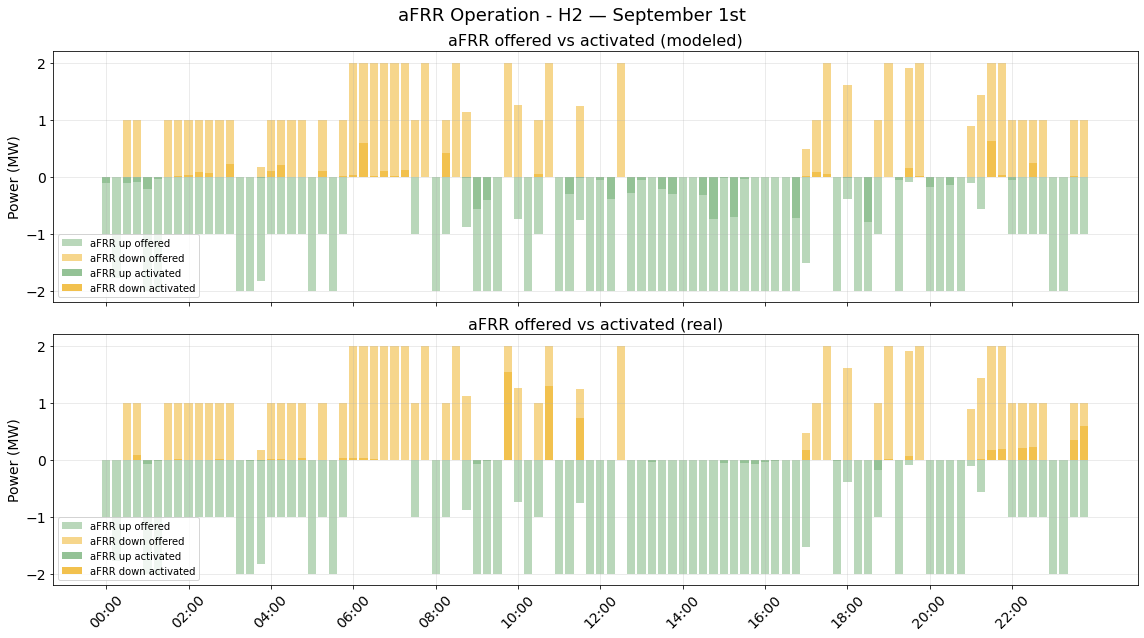

In [62]:
def plot_bandas_september_1st(df):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    PALETTE = ["#1f4e79", "#7d9fb0", "#94c296", "#f2c14e"]

    df = df.copy()
    df["datetime"] = df["datetime"].apply(
        lambda x: pd.Timestamp(x).tz_convert("Europe/Madrid")
    )

    # -------------------------------------------------
    # 1. Filtrar solo el 1 de septiembre
    # -------------------------------------------------
    df_day = df[df['datetime'].dt.date == pd.Timestamp("2025-09-01").date()]

    if len(df_day) != 96:
        print(f"⚠️ Aviso: el día tiene {len(df_day)} registros en lugar de 96")

    # -------------------------------------------------
    # 2. Quarter-hour del día
    # -------------------------------------------------
    df_day["quarter"] = (
        df_day["datetime"].dt.hour * 4
        + df_day["datetime"].dt.minute // 15
    )
    df_day = df_day.sort_values("quarter")

    qh = np.arange(96)
    time_labels = [
        (pd.Timestamp("2000-01-01") + pd.Timedelta(minutes=15*q)).strftime("%H:%M")
        for q in qh
    ]

    # -------------------------------------------------
    # 3. Colores (convención correcta)
    # -------------------------------------------------
    colors = {
        "up": PALETTE[2],     # verde → subir
        "down": PALETTE[3],   # amarillo → bajar
    }

    # -------------------------------------------------
    # 4. Figura
    # -------------------------------------------------
    fig, ax = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

    # =================================================
    # GRÁFICO 1 — Activación histórica (modelada)
    # =================================================
    ax0 = ax[0]

    # Offered
    ax0.bar(
        qh,
        -df_day["banda_up_offered_MW"],
        color=colors["up"],
        alpha=0.65,
        label="aFRR up offered"
    )
    ax0.bar(
        qh,
        df_day["banda_down_offered_MW"],
        color=colors["down"],
        alpha=0.65,
        label="aFRR down offered"
    )

    # Activated
    ax0.bar(
        qh,
        -df_day["banda_up_activated_MW"],
        color=colors["up"],
        alpha=1,
        label="aFRR up activated"
    )
    ax0.bar(
        qh,
        df_day["banda_down_activated_MW"],
        color=colors["down"],
        alpha=1,
        label="aFRR down activated"
    )

    ax0.set_title("aFRR offered vs activated (modeled)", fontsize=16)
    ax0.set_ylabel("Power (MW)", fontsize=14)
    ax0.tick_params(axis='x', labelsize=14)
    ax0.tick_params(axis='y', labelsize=14)
    ax0.legend(loc="lower left")
    ax0.grid(alpha=0.3)

    # =================================================
    # GRÁFICO 2 — Nueva activación simulada (real)
    # =================================================
    ax1 = ax[1]

    # Offered
    ax1.bar(
        qh,
        -df_day["banda_up_offered_MW"],
        color=colors["up"],
        alpha=0.65,
        label="aFRR up offered"
    )
    ax1.bar(
        qh,
        df_day["banda_down_offered_MW"],
        color=colors["down"],
        alpha=0.65,
        label="aFRR down offered"
    )

    # Activated
    ax1.bar(
        qh,
        -df_day["new_banda_up_activated_MW"],
        color=colors["up"],
        alpha=1,
        label="aFRR up activated"
    )
    ax1.bar(
        qh,
        df_day["new_banda_down_activated_MW"],
        color=colors["down"],
        alpha=1,
        label="aFRR down activated"
    )

    ax1.set_title("aFRR offered vs activated (real)", fontsize=16)
    ax1.set_ylabel("Power (MW)", fontsize=14)
    ax1.tick_params(axis='x', labelsize=14)
    ax1.tick_params(axis='y', labelsize=14)
    ax1.set_xticks(np.arange(0, 96, 8))
    ax1.set_xticklabels(time_labels[::8], rotation=45)
    ax1.legend(loc="lower left")
    ax1.grid(alpha=0.3)

    # -------------------------------------------------
    plt.suptitle("aFRR Operation - H2 — September 1st", fontsize=18)
    plt.tight_layout()
    plt.savefig('../data/backtesting_results/images/afrr_operation_september_1st_colored.pdf', dpi=300)
    plt.show()


df = pd.read_csv(
    "../data/backtesting_results/activation/real_activation/profit_corrected_with_spot/with_activation/"
    "corrected_expost_optimization_horizon_2_days_SRS.csv"
)
plot_bandas_september_1st(df)

C:\Users\User\AppData\Local\Temp/ipykernel_384/3203660788.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day["quarter"] = (
No handles with labels found to put in legend.


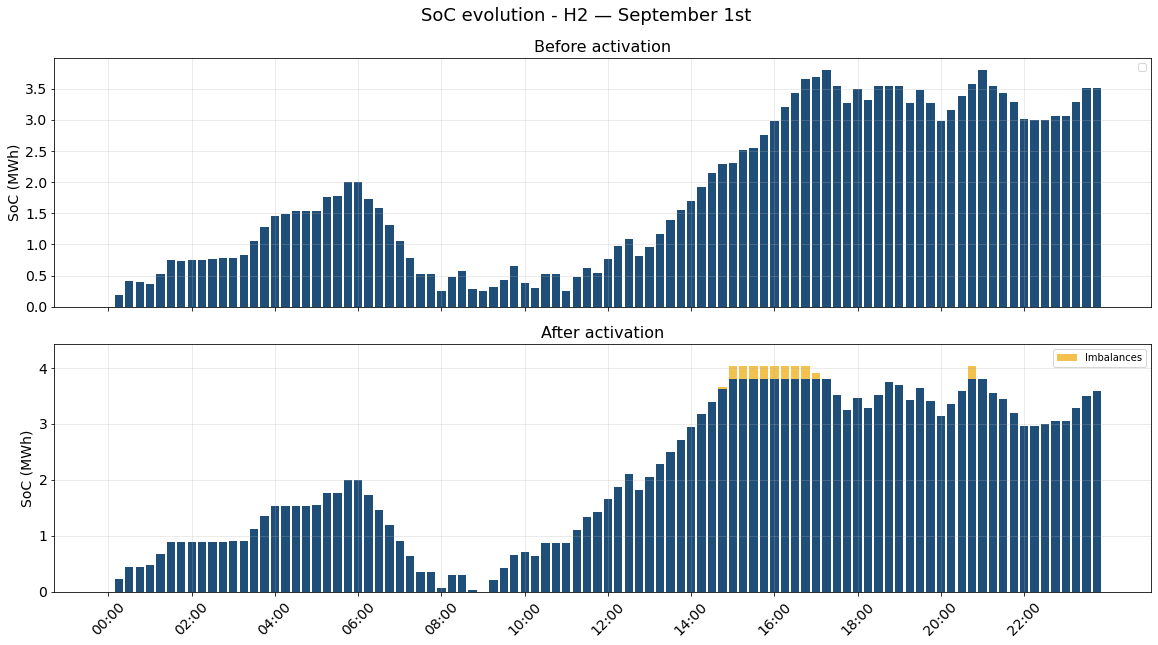

In [61]:
def plot_soc_post_activated(df):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    PALETTE = ["#1f4e79", "#7d9fb0", "#94c296", "#f2c14e"]

    df = df.copy()
    df["datetime"] = df["datetime"].apply(
        lambda x: pd.Timestamp(x).tz_convert("Europe/Madrid")
    )

    # -------------------------------------------------
    # 1. Filtrar solo el 1 de septiembre
    # -------------------------------------------------
    df_day = df[df['datetime'].dt.date == pd.Timestamp("2025-09-01").date()]

    if len(df_day) != 96:
        print(f"⚠️ Aviso: el día tiene {len(df_day)} registros en lugar de 96")

    # -------------------------------------------------
    # 2. Quarter-hour del día
    # -------------------------------------------------
    df_day["quarter"] = (
        df_day["datetime"].dt.hour * 4
        + df_day["datetime"].dt.minute // 15
    )
    df_day = df_day.sort_values("quarter")

    qh = np.arange(96)
    time_labels = [
        (pd.Timestamp("2000-01-01") + pd.Timedelta(minutes=15*q)).strftime("%H:%M")
        for q in qh
    ]


    fig, ax = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
    ax1 = ax[0]
    ax1.bar(qh, df_day["soc_start_MWh"], color="#1f4e79")
    ax1.set_title("Before activation", fontsize=16)
    ax1.set_ylabel("SoC (MWh)", fontsize=14)
    ax1.set_xticks(np.arange(0, 96, 8))
    ax1.set_xticklabels(time_labels[::8], rotation=45)
    ax1.tick_params(axis='x', labelsize=14)
    ax1.tick_params(axis='y', labelsize=14)
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2 = ax[1]
    ax2.bar(qh, df_day["new_soc_MWh"], color="#1f4e79")
    ax2.bar(qh, - df_day["soc_imbalance_down_MW"], color="#f2c14e")   
    ax2.bar(qh, df_day["soc_imbalance_up_MW"], bottom=df_day["new_soc_MWh"], label="Imbalances", color="#f2c14e")

    ymin = -df_day["soc_imbalance_down_MW"].max() * 1.1
    ymax = (df_day["new_soc_MWh"] + df_day["soc_imbalance_up_MW"]).max() * 1.1
    ax2.set_ylim(ymin, ymax)
    ax2.set_title("After activation", fontsize=16)
    ax2.set_ylabel("SoC (MWh)", fontsize=14)
    ax2.set_xticks(np.arange(0, 96, 8))
    ax2.set_xticklabels(time_labels[::8], rotation=45)
    ax2.tick_params(axis='x', labelsize=14)
    ax2.tick_params(axis='y', labelsize=14)
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.suptitle("SoC evolution - H2 — September 1st", fontsize=18, y=0.99)    
    plt.tight_layout()
    plt.savefig('../data/backtesting_results/images/soc_operation_september_1st_colored.pdf', dpi=300)
    plt.show()


df = pd.read_csv(
    "../data/backtesting_results/activation/real_activation/profit_corrected_with_spot/with_activation/"
    "corrected_expost_optimization_horizon_2_days_SRS.csv"
)
plot_soc_post_activated(df)

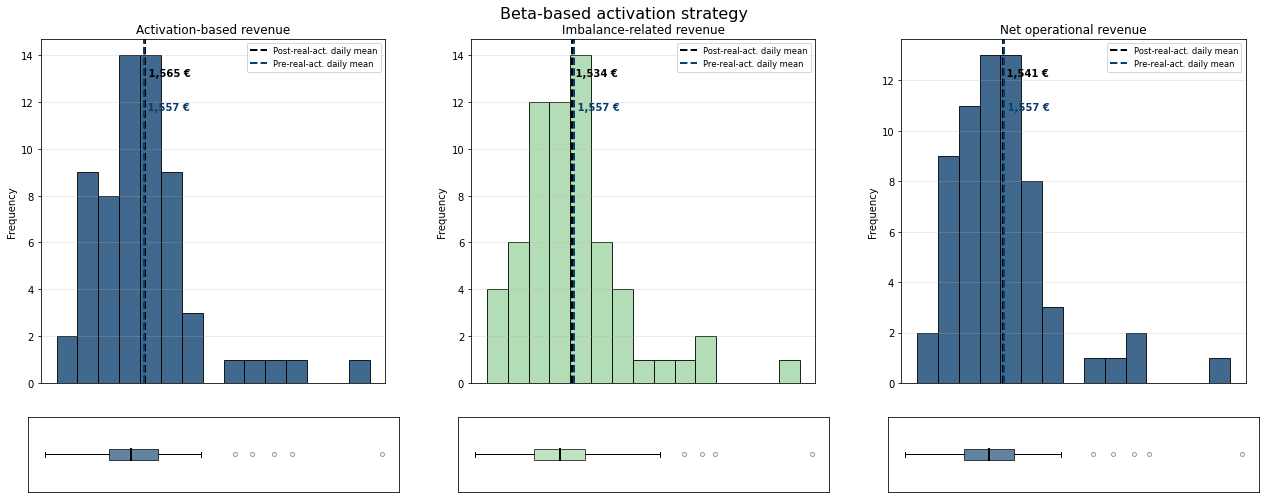

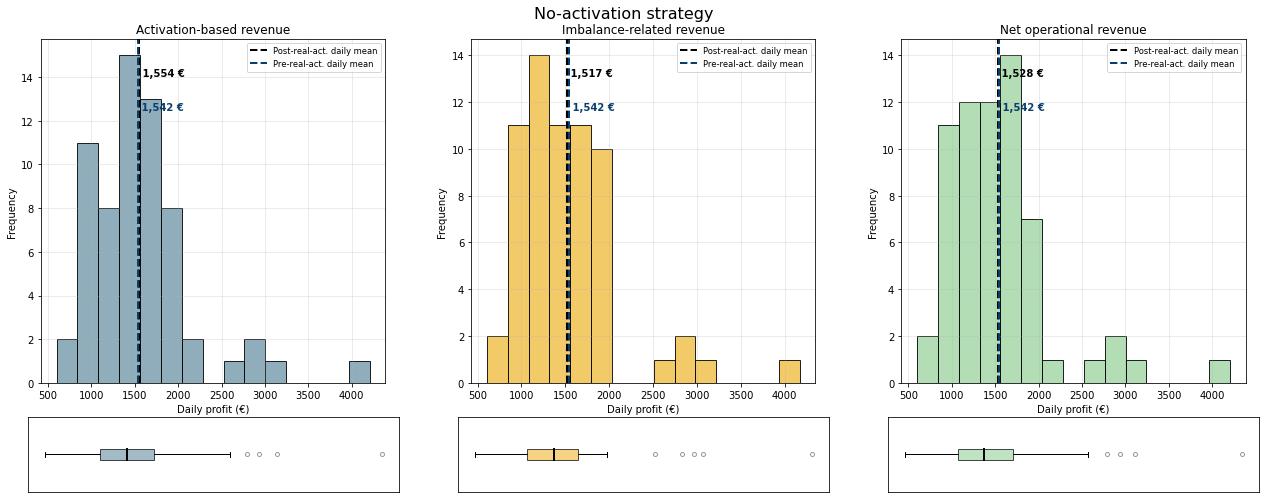

In [ ]:
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec
import matplotlib.patheffects as pe

DT_H = 0.25  # quarter hour

# ==========================
# Paths
# ==========================
PATH_WITH = (
    "../data/backtesting_results/activation/real_activation/"
    "profit_corrected_with_spot/with_activation/"
    "corrected_expost_optimization_horizon_2_days_SRS.csv"
)

PATH_WITHOUT = (
    "../data/backtesting_results/activation/real_activation/"
    "profit_corrected_with_spot/without_activation/"
    "corrected_expost_optimization_horizon_2_days_SRS_cycled.csv"
)

# ==========================
# Palette
# ==========================
PALETTE = ["#1f4e79","#7d9fb0","#a6d8a8", "#f2c14e"]

# ==========================
# Helper functions
# ==========================
def prepare_df(path):
    df = pd.read_csv(path)
    df["datetime"] = df["datetime"].apply(
        lambda x: pd.Timestamp(x).tz_convert("Europe/Madrid")
    )
    # Same definitions as in your function
    df["profit_imbalances"] = (
        df["spot_revenue_EUR"]
        + df["banda_revenue_EUR"]
        + df["cost_imbalance_up_soc"]
        - df["cost_imbalance_down_soc"]
        - df["cost_imbalance_up_esec"]
        - df["cost_imbalance_down_esec"]
    )

    df["profit_esec"] = (
        df["spot_revenue_EUR"]
        + df["banda_revenue_EUR"]
        + df["cost_esec_up"]
        - df["cost_esec_down"]
    )

    return df


def daily_profit(df, col):
    return (
        df.groupby(df["datetime"].dt.date)[col]
        .sum()
        .values
    )


def plot_hist(ax, data, originaldata, title, color):
    ax.hist(data, bins=15, color=color, alpha=0.85, edgecolor="black")
    ax.axvline(data.mean(), linestyle="--", linewidth=2, color="black", label= "Post-real-act. daily mean")
    ax.text(
        data.mean(),
        ax.get_ylim()[1] * 0.9,
        f" {data.mean():,.0f} €",
        verticalalignment="center",
        color="black",
        fontsize=10,
        fontweight="bold"
    )
    ax.axvline(originaldata.mean(), linestyle="--", linewidth=2, color="#093d6e", label= "Pre--real-act. daily mean")
    ax.text(
        originaldata.mean(),
        ax.get_ylim()[1] * 0.8,
        f" {originaldata.mean():,.0f} €",
        verticalalignment="center",
        color="#093d6e",
        fontsize=10,
        fontweight="bold"
    )
    ax.set_title(title)
    ax.set_xlabel("Daily profit (€)")
    ax.set_ylabel("Frequency")
    ax.legend(loc= "upper right", fontsize='small')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(alpha=0.3)

    
def plot_boxplot(ax, data, color):
    ax.boxplot(
        data,
        vert=False,                  
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.7),
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        flierprops=dict(marker='o', markersize=4, alpha=0.4)
    )
    ax.set_xticks([])  
    ax.set_yticks([])                   
    ax.grid(alpha=0.3)


# ==========================
# Load & prepare data
# ==========================
df_with = prepare_df(PATH_WITH)
df_without = prepare_df(PATH_WITHOUT)

# ==========================
# Build figure (2 x 3)
# ==========================
fig = plt.figure(figsize=(18, 7.5))

gs = GridSpec(
    nrows=2,
    ncols=3,
    width_ratios=[1, 1, 1],
    height_ratios=[1, 0.22],
    hspace=0.16,
    wspace=0.16
)

axes = np.empty((2, 3), dtype=object)
for i in range(2):
    for j in range(3):
        axes[i, j] = fig.add_subplot(gs[i, j])

# ---- profit_esec
plot_hist(
    axes[0, 0],
    daily_profit(df_with, "profit_esec"),
    daily_profit(df_with, "net_profit_EUR"),
    "Activation-based revenue",
    PALETTE[1],
)
plot_boxplot(
    axes[1, 0],
    daily_profit(df_with, "profit_esec"),
    PALETTE[1],
)

# ---- profit_imbalances
plot_hist(
    axes[0, 1],
    daily_profit(df_with, "profit_imbalances"),
    daily_profit(df_with, "net_profit_EUR"),
    "Imbalance-related revenue",
    PALETTE[3],
)
plot_boxplot(
    axes[1, 1],
    daily_profit(df_with, "profit_imbalances"),
    PALETTE[3],
)

# ---- profit_corrected
plot_hist(
    axes[0, 2],
    daily_profit(df_with, "profit_corrected"),
    daily_profit(df_with, "net_profit_EUR"),
    "Net operational revenue",
    PALETTE[2],
)
plot_boxplot(
    axes[1, 2],
    daily_profit(df_with, "profit_corrected"),
    PALETTE[2],
)

# ---- Ajustes finales
for j in range(3):
    # Histogramas cuadrados y sin eje X
    axes[0, j].set_box_aspect(1)

fig.suptitle(
    "Beta-based activation strategy",
    fontsize=16,
    x=0.5,          # centro horizontal exacto
    y=0.98         # altura (ajústalo fino)
)
plt.subplots_adjust(
    left=0.04,
    right=0.99,
    top=0.92,
    bottom=0.08
)

plt.savefig(
    "../data/backtesting_results/images/daily_profit_comparison_activation_boxplot.pdf",
    dpi=300
)
plt.show()


fig = plt.figure(figsize=(18, 7.5))

gs = GridSpec(
    nrows=2,
    ncols=3,
    width_ratios=[1, 1, 1],
    height_ratios=[1, 0.22],
    hspace=0.16,
    wspace=0.16
)

axes = np.empty((2, 3), dtype=object)
for i in range(2):
    for j in range(3):
        axes[i, j] = fig.add_subplot(gs[i, j])

# ---- profit_esec
plot_hist(
    axes[0, 0],
    daily_profit(df_without, "profit_esec"),
    daily_profit(df_without, "net_profit_EUR"),
    "Activation-based revenue",
    PALETTE[1],
)
plot_boxplot(
    axes[1, 0],
    daily_profit(df_without, "profit_esec"),
    PALETTE[1],
)

# ---- profit_imbalances
plot_hist(
    axes[0, 1],
    daily_profit(df_without, "profit_imbalances"),
    daily_profit(df_without, "net_profit_EUR"),
    "Imbalance-related revenue",
    PALETTE[3],
)
plot_boxplot(
    axes[1, 1],
    daily_profit(df_without, "profit_imbalances"),
    PALETTE[3],
)

# ---- profit_corrected
plot_hist(
    axes[0, 2],
    daily_profit(df_without, "profit_corrected"),
    daily_profit(df_without, "net_profit_EUR"),
    "Net operational revenue",
    PALETTE[2],
)
plot_boxplot(
    axes[1, 2],
    daily_profit(df_without, "profit_corrected"),
    PALETTE[2],
)

# ---- Ajustes finales
for j in range(3):
    # Histogramas cuadrados y sin eje X
    axes[0, j].set_box_aspect(1)

fig.suptitle(
    "No-activation strategy",
    fontsize=16,
    x=0.5,          # centro horizontal exacto
    y=0.98         # altura (ajústalo fino)
)
plt.subplots_adjust(
    left=0.04,
    right=0.99,
    top=0.92,
    bottom=0.08
)

plt.savefig(
    "../data/backtesting_results/images/daily_profit_comparison_nonactivation_boxplot.pdf",
    dpi=300
)
plt.show()

€/ciclo sin activación: 237.10
€/ciclo con activación: 184.46
€/ciclo sin activación (días con activación): 323.70
R² sin activación: 0.213
R² con activación: 0.007
R² sin activación (días con activación): 0.021
Model 1 -> slope: -3.6110516771256003 R²: 0.0034759029849781298
Model 2 -> slope: -0.34247264439197184 R²: 0.00040605537619453624
Model 3 -> slope: -2.450519321251048 R²: 0.0016036640601743146


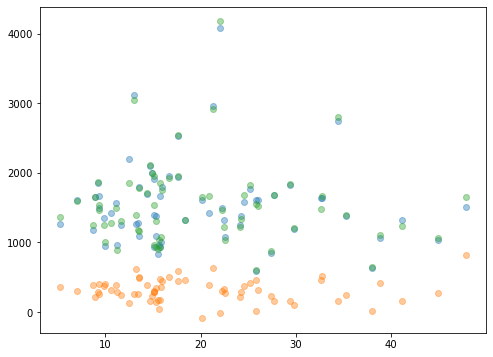

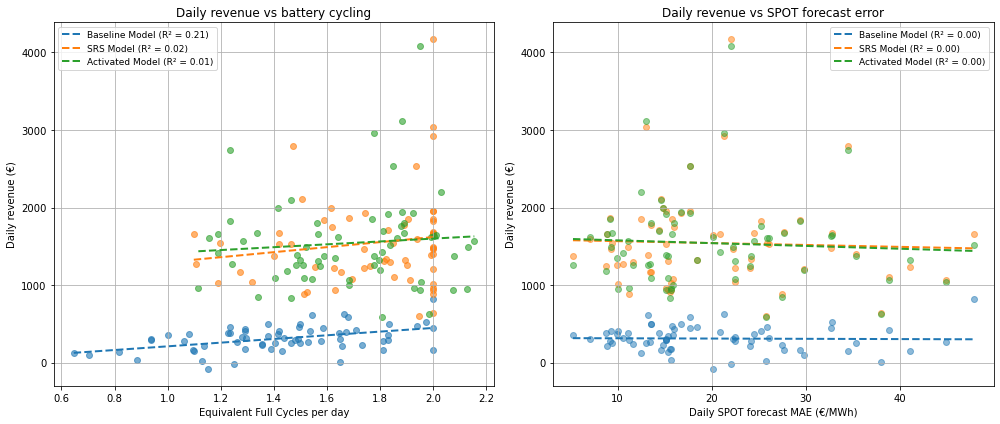

In [8]:

#CYCLED REVENUE
df = pd.read_csv(
    "../data/backtesting_results/activation/real_activation/profit_corrected_with_spot/with_activation/corrected_expost_optimization_horizon_2_days_SRS.csv"
)

df2 = pd.read_csv(
    "../data/backtesting_results/results_efficiency/expost_optimization_horizon_2_days_baseline_cycled.csv"
)

df3 = pd.read_csv(
    "../data/backtesting_results/results_efficiency/expost_optimization_horizon_2_days_SRS_cycled.csv"
)

E_CAP_MWh = 3.8

# ===============================
# PREPROCESADO
# ===============================
df["datetime"] = df["datetime"].apply(
    lambda x: pd.Timestamp(x).tz_convert("Europe/Madrid")
)

df2["datetime"] = df2["datetime"].apply(
    lambda x: pd.Timestamp(x).tz_convert("Europe/Madrid")
)

df3["datetime"] = df3["datetime"].apply(
    lambda x: pd.Timestamp(x).tz_convert("Europe/Madrid")   
)

df = df.sort_values("datetime").reset_index(drop=True)
df2 = df2.sort_values("datetime").reset_index(drop=True)
df3 = df3.sort_values("datetime").reset_index(drop=True)

df["date"] = df["datetime"].dt.date
df2["date"] = df2["datetime"].dt.date
df3["date"] = df3["datetime"].dt.date

# ===============================
# CÁLCULO DE CICLOS
# ===============================
df2["delta_soc_before"] = df2["soc_start_MWh"].diff(-1).abs()
df3['delta_soc_before']   = df3["soc_start_MWh"].diff(-1).abs()
df["delta_soc_after"]   = df["new_soc_MWh"].diff(-1).abs()

# ===============================
# AGREGACIÓN DIARIA
# ===============================
df_daily = (
    df.groupby("date")
      .agg(
          throughput_after=("delta_soc_after", "sum"),
          revenue_after=("profit_corrected", "sum"),
      )
)

df2_daily = (
    df2.groupby("date")
       .agg(
           throughput_before=("delta_soc_before", "sum"),
           revenue_before=("net_profit_EUR", "sum"),
       )
)

df3_daily = (
    df3.groupby("date")
       .agg(
           throughput_before=("delta_soc_before", "sum"),
           revenue_before=("net_profit_EUR", "sum"),
       )
)

df3_daily['EFC_before'] = df3_daily['throughput_before'] / (2 * E_CAP_MWh)
df_daily["EFC_after"]   = df_daily["throughput_after"]  / (2 * E_CAP_MWh)
df2_daily["EFC_before"] = df2_daily["throughput_before"] / (2 * E_CAP_MWh)

df_daily  = df_daily[df_daily["EFC_after"] > 0]
df3_daily = df3_daily[df3_daily["EFC_before"] > 0]
df2_daily = df2_daily[df2_daily["EFC_before"] > 0]

# ===============================
# REGRESIONES LINEALES
# ===============================
# --- Sin activación ---
coef_before = np.polyfit(
    df2_daily["EFC_before"],
    df2_daily["revenue_before"],
    deg=1
)

y_pred_before = (
    coef_before[0] * df2_daily["EFC_before"] + coef_before[1]
)

# --- Con activación ---
coef_after = np.polyfit(
    df_daily["EFC_after"],
    df_daily["revenue_after"],
    deg=1
)

y_pred_after = (
    coef_after[0] * df_daily["EFC_after"] + coef_after[1]
)

coef_before2 = np.polyfit(
    df3_daily["EFC_before"],
    df3_daily["revenue_before"],
    deg=1
)

y_pred_before2 = (
    coef_before2[0] * df3_daily["EFC_before"] + coef_before2[1]
)

# ===============================
# R²
# ===============================
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

r2_before = r2_score(df2_daily["revenue_before"], y_pred_before)
r2_before2 = r2_score(df3_daily["revenue_before"], y_pred_before2)
r2_after  = r2_score(df_daily["revenue_after"],  y_pred_after)

# Rectas para el gráfico
x_before = np.linspace(
    df2_daily["EFC_before"].min(),
    df2_daily["EFC_before"].max(),
    100
)

x2_before = np.linspace(
    df3_daily["EFC_before"].min(),
    df3_daily["EFC_before"].max(),
    100
)

y_before = coef_before[0] * x_before + coef_before[1]

y2_before = coef_before2[0] * x2_before + coef_before2[1]

x_after = np.linspace(
    df_daily["EFC_after"].min(),
    df_daily["EFC_after"].max(),
    100
)

y_after = coef_after[0] * x_after + coef_after[1]

# ===============================
# GRÁFICO FINAL
# ===============================
# plt.figure(figsize=(8, 6))

# plt.scatter(
#     df2_daily["EFC_before"],
#     df2_daily["revenue_before"],
#     alpha=0.6,
#     label="Without activation",
# )

# plt.scatter(
#     df3_daily["EFC_before"],
#     df3_daily["revenue_before"],
#     alpha=0.6,
#     label="Without activation (days with activation data)",
# )

# plt.scatter(
#     df_daily["EFC_after"],
#     df_daily["revenue_after"],
#     alpha=0.6,
#     label="With activation",
# )

# plt.plot(
#     x_before, y_before,
#     linestyle="--",
#     linewidth=2,
#     label=f"No activation fit (R² = {r2_before:.2f})",
# )

# plt.plot(
#     x2_before, y2_before,
#     linestyle="--",
#     linewidth=2,
#     label=f"No activation fit (days with activation data) (R² = {r2_before2:.2f})",
# )

# plt.plot(
#     x_after, y_after,
#     linestyle="--",
#     linewidth=2,
#     label=f"With activation fit (R² = {r2_after:.2f})",
# )

# plt.xlabel("Equivalent Full Cycles per day")
# plt.ylabel("Daily revenue (€)")
# plt.title("Daily revenue vs battery cycling")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# ===============================
# INFO CLAVE PARA EL TFM
# ===============================
print(f"€/ciclo sin activación: {coef_before[0]:.2f}")
print(f"€/ciclo con activación: {coef_after[0]:.2f}")
print(f"€/ciclo sin activación (días con activación): {coef_before2[0]:.2f}")
print(f"R² sin activación: {r2_before:.3f}")
print(f"R² con activación: {r2_after:.3f}")
print(f"R² sin activación (días con activación): {r2_before2:.3f}")
def daily_revenue_vs_mae(df_base, df_errors, activation=False):
    """
    Calcula revenue diario, MAE diario, regresión lineal y R²
    """
    df = pd.merge(
        df_base,
        df_errors,
        on="datetime",
        how="left"
    ).copy()

    df["date"] = df["datetime"].dt.date

    if activation: 
        df_daily = (
            df.groupby("date")
            .agg(
                daily_revenue=("profit_corrected", "sum"),
                spot_mae=("SPOT_abs_error", "mean"),
            )
            .dropna()
        )
    else:
        df_daily = (
            df.groupby("date")
            .agg(
                daily_revenue=("net_profit_EUR", "sum"),
                spot_mae=("SPOT_abs_error", "mean"),
            )
            .dropna()
        )

    # Regresión lineal
    coef = np.polyfit(
        df_daily["spot_mae"],
        df_daily["daily_revenue"],
        deg=1
    )

    y_pred = coef[0] * df_daily["spot_mae"] + coef[1]

    # R²
    ss_res = np.sum((df_daily["daily_revenue"] - y_pred) ** 2)
    ss_tot = np.sum((df_daily["daily_revenue"] - df_daily["daily_revenue"].mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    return df_daily, coef, r2


# =====================================================
# CARGA Y PREPARACIÓN DE ERRORES SPOT (df4)
# =====================================================
df4 = pd.read_csv(
    "../data/backtesting_results/prediction_errors_horizon_32_days_SRS.csv"
)

df4["datetime"] = df4["datetime"].apply(
    lambda x: pd.Timestamp(x).tz_convert("Europe/Madrid")
)

# Seleccionar solo los días deseados
mask = df4["BANDA_subir_days_since_start"] == 1
df4_sel = df4.loc[mask, ["datetime", "SPOT_abs_error"]]

# =====================================================
# ASEGURAR FORMATO DE datetime EN df, df2, df3
# =====================================================
for df_tmp in [df, df2, df3]:
    df_tmp["datetime"] = pd.to_datetime(df_tmp["datetime"])

# =====================================================
# EJECUTAR REGRESIONES
# =====================================================
df_daily_1, coef_1, r2_1 = daily_revenue_vs_mae(df, df4_sel, activation=True)
df_daily_2, coef_2, r2_2 = daily_revenue_vs_mae(df2, df4_sel)
df_daily_3, coef_3, r2_3 = daily_revenue_vs_mae(df3, df4_sel)

# =====================================================
# GRÁFICO ÚNICO CON LAS 3 REGRESIONES
# =====================================================
plt.figure(figsize=(8, 6))

# Scatter (uno por modelo)
plt.scatter(df_daily_1["spot_mae"], df_daily_1["daily_revenue"], alpha=0.4)
plt.scatter(df_daily_2["spot_mae"], df_daily_2["daily_revenue"], alpha=0.4)
plt.scatter(df_daily_3["spot_mae"], df_daily_3["daily_revenue"], alpha=0.4)

# Función para dibujar cada regresión
def plot_regression(df_daily, coef, label, r2):
    x = np.linspace(df_daily["spot_mae"].min(), df_daily["spot_mae"].max(), 100)
    y = coef[0] * x + coef[1]
    plt.plot(
        x, y,
        linestyle="--",
        linewidth=2,
        label=f"{label} (R² = {r2:.2f})"
    )

# plot_regression(df_daily_1, coef_1, "Model 1", r2_1)
# plot_regression(df_daily_2, coef_2, "Model 2", r2_2)
# plot_regression(df_daily_3, coef_3, "Model 3", r2_3)

# plt.xlabel("Daily SPOT forecast MAE (€/MWh)")
# plt.ylabel("Daily revenue (€)")
# plt.title("Daily revenue vs SPOT forecast error")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# =====================================================
# INFORMACIÓN NUMÉRICA (POR SI LA QUIERES CITAR)
# =====================================================
print("Model 1 -> slope:", coef_1[0], "R²:", r2_1)
print("Model 2 -> slope:", coef_2[0], "R²:", r2_2)
print("Model 3 -> slope:", coef_3[0], "R²:", r2_3)

# ===============================
# FUNCIÓN R²
# ===============================
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot


# ===============================
# FIGURA CON DOS SUBPLOTS
# ===============================
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharey=False
)

# =====================================================
# (a) REVENUE vs CICLOS
# =====================================================
ax = axes[0]

# Scatter
ax.scatter(
    df2_daily["EFC_before"],
    df2_daily["revenue_before"],
    alpha=0.6
)

ax.scatter(
    df3_daily["EFC_before"],
    df3_daily["revenue_before"],
    alpha=0.6
)

ax.scatter(
    df_daily["EFC_after"],
    df_daily["revenue_after"],
    alpha=0.6
)

# Regresiones
ax.plot(
    x_before, y_before,
    linestyle="--",
    linewidth=2,
    label=f"Baseline Model (R² = {r2_before:.2f})",
)

ax.plot(
    x2_before, y2_before,
    linestyle="--",
    linewidth=2,
    label=f"SRS Model (R² = {r2_before2:.2f})",
)

ax.plot(
    x_after, y_after,
    linestyle="--",
    linewidth=2,
    label=f"Activated Model (R² = {r2_after:.2f})",
)

ax.set_xlabel("Equivalent Full Cycles per day")
ax.set_ylabel("Daily revenue (€)")
ax.set_title("Daily revenue vs battery cycling")
ax.grid(True)
ax.legend(fontsize=9)


# =====================================================
# (b) REVENUE vs MAE SPOT
# =====================================================
ax = axes[1]

# Scatter

ax.scatter(df_daily_2["spot_mae"], df_daily_2["daily_revenue"], alpha=0.5)
ax.scatter(df_daily_3["spot_mae"], df_daily_3["daily_revenue"], alpha=0.5)
ax.scatter(df_daily_1["spot_mae"], df_daily_1["daily_revenue"], alpha=0.5)

# Función para dibujar regresión
def plot_reg(ax, df_daily, coef, label, r2):
    x = np.linspace(df_daily["spot_mae"].min(), df_daily["spot_mae"].max(), 100)
    y = coef[0] * x + coef[1]
    ax.plot(
        x, y,
        linestyle="--",
        linewidth=2,
        label=f"{label} (R² = {r2:.2f})"
    )


plot_reg(ax, df_daily_2, coef_2, "Baseline Model", r2_2)
plot_reg(ax, df_daily_3, coef_3, "SRS Model", r2_3)
plot_reg(ax, df_daily_1, coef_1, "Activated Model", r2_1)

ax.set_xlabel("Daily SPOT forecast MAE (€/MWh)")
ax.set_ylabel("Daily revenue (€)")
ax.set_title("Daily revenue vs SPOT forecast error")
ax.grid(True)
ax.legend(fontsize=9)

# ===============================
# AJUSTES FINALES
# ===============================
plt.tight_layout()

# plt.savefig(
#     "data/backtesting_results/images/daily_revenue_drivers_combined.pdf",
#     dpi=300
# )
plt.show()

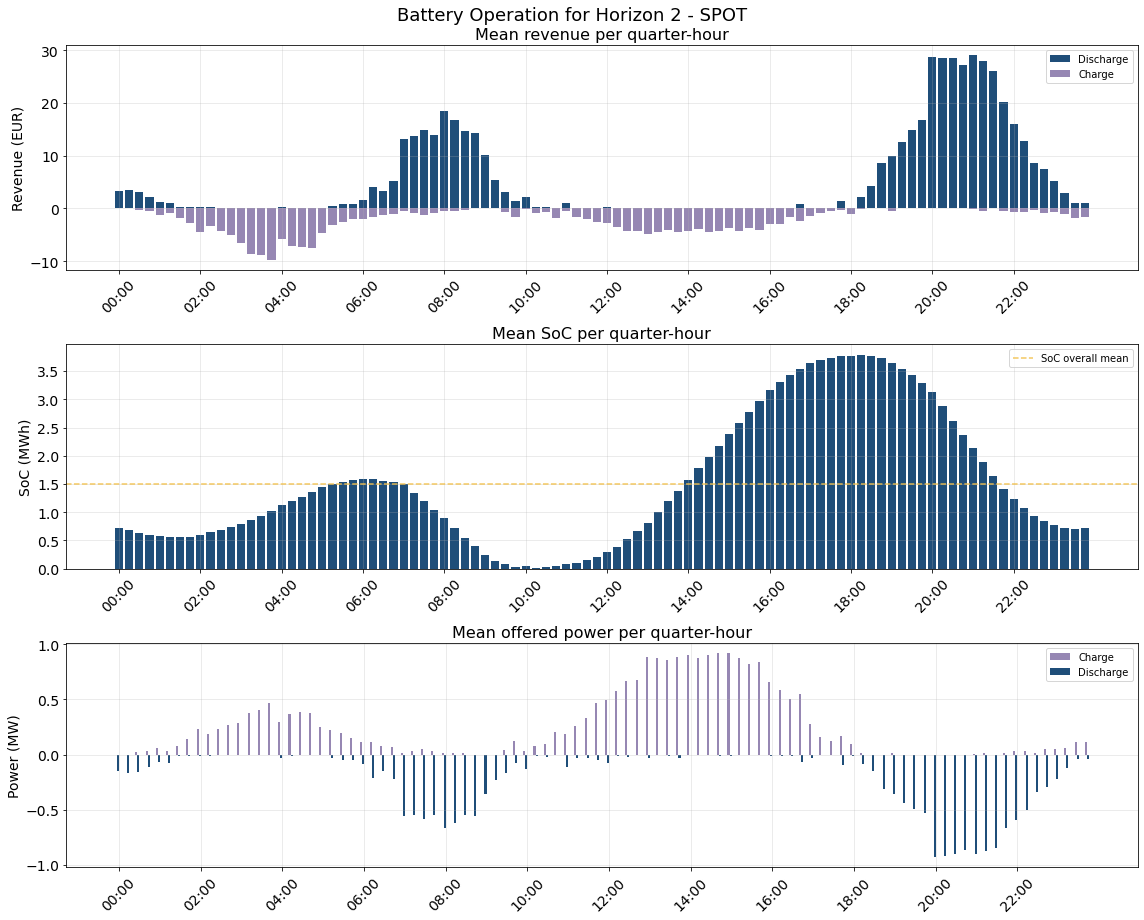

In [8]:

def plot_revenue_and_power(df):

    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
    df['datetime'] = df['datetime'].dt.tz_convert('Europe/Madrid')

    # ---------------------------
    # 1. Quarter-of-day
    # ---------------------------
    df["quarter"] = df["datetime"].dt.hour * 4 + df["datetime"].dt.minute // 15

    # ---------------------------
    # 2. Crear columnas de revenue desglosado
    # ---------------------------
    df["spot_charge_rev"] = np.where(df["charge_base_MW"] > 0, df["spot_revenue_EUR"], 0)
    df["spot_discharge_rev"] = np.where(df["discharge_base_MW"] > 0, df["spot_revenue_EUR"], 0)

    # ---------------------------
    # 3. Agrupar por QH
    # ---------------------------
    group_cols = ["spot_discharge_rev", "spot_charge_rev", "charge_base_MW", "discharge_base_MW", "soc_start_MWh"]

    grouped = df.groupby("quarter")[group_cols].mean()

    # ---------------------------
    # 4. Preparar eje X
    # ---------------------------
    qh = np.arange(96)
    time_labels = [(pd.Timestamp("2000-01-01") + pd.Timedelta(minutes=15*q)).strftime("%H:%M")
                   for q in qh]

    # ===========================
    # FIGURA (a) — REVENUES
    # ===========================

    fig, ax = plt.subplots(3, 1, figsize=(16, 13))

    ax0 = ax[0]

    # Lista de columnas y estilos
    components = [
        ("spot_discharge_rev", "#1f4e79", "Discharge"),
        ("spot_charge_rev",    "#9687b3", "Charge")
    ]

    # Inicializamos los acumulados de positivos y negativos
    pos_bottom = np.zeros(len(grouped))
    neg_bottom = np.zeros(len(grouped))

    for col, color, label in components:
        series = grouped[col].values

        # Parte positiva y negativa
        pos = np.clip(series, 0, None)   # >= 0
        neg = np.clip(series, None, 0)   # <= 0

        # Positivos: apilados hacia arriba
        if np.any(pos != 0):
            ax0.bar(qh, pos, bottom=pos_bottom, color=color)
            pos_bottom += pos

        # Negativos: apilados hacia abajo
        if np.any(neg != 0):
            ax0.bar(qh, neg, bottom=neg_bottom, color=color, label=label)
            neg_bottom += neg

    ax0.set_title("Mean revenue per quarter-hour", fontsize=16)
    ax0.set_ylabel("Revenue (EUR)", fontsize=14)
    ax0.set_xticks(np.arange(0, 96, 8))
    ax0.set_xticklabels(time_labels[::8], rotation=45)
    ax0.tick_params(axis='x', labelsize=14)
    ax0.tick_params(axis='y', labelsize=14)
    ax0.legend()
    ax0.grid(alpha=0.3)

# Gráfico de SoC

    ax2 = ax[1]
    ax2.bar(qh, grouped["soc_start_MWh"], color="#1f4e79")
    med = grouped["soc_start_MWh"].mean()
    med_color = "#f2c14e"
    ax2.axhline(
                med,
                linestyle="--",
                color=med_color,
                alpha=0.9, 
                label="SoC overall mean"
            )
    ax2.set_title("Mean SoC per quarter-hour", fontsize=16)
    ax2.set_ylabel("SoC (MWh)", fontsize=14)
    ax2.set_xticks(np.arange(0, 96, 8))
    ax2.set_xticklabels(time_labels[::8], rotation=45)
    ax2.tick_params(axis='x', labelsize=14)
    ax2.tick_params(axis='y', labelsize=14)
    ax2.legend()
    ax2.grid(alpha=0.3)


    # ===========================
    # FIGURA (b) — POWER OFFERED
    # ===========================

    ax1 = ax[2]

    width = 0.2

    ax1.bar(qh - 1.5*width, grouped["charge_base_MW"], width, label="Charge", color="#9687b3")
    ax1.bar(qh - 0.5*width, -grouped["discharge_base_MW"], width, label="Discharge", color="#1f4e79")

    ax1.set_title("Mean offered power per quarter-hour", fontsize=16)
    ax1.set_ylabel("Power (MW)", fontsize=14)
    ax1.set_xticks(np.arange(0, 96, 8))
    ax1.set_xticklabels(time_labels[::8], rotation=45)
    ax1.tick_params(axis='x', labelsize=14)
    ax1.tick_params(axis='y', labelsize=14)
    ax1.legend()
    ax1.grid(alpha=0.3)

    plt.suptitle("Battery Operation for Horizon 2 - SPOT", fontsize=18)
    plt.tight_layout()
    plt.savefig('../data/backtesting_results/images/battery_operation_horizon_2_baseline_cycled.pdf', dpi=300)
    plt.show()



df = pd.read_csv(
    "../data/backtesting_results/files_revenues_qh_cycled/"
    "revenues_qh_strategies_horizon_2_baseline_cycled_Ex-post.csv"
)

plot_revenue_and_power(df)

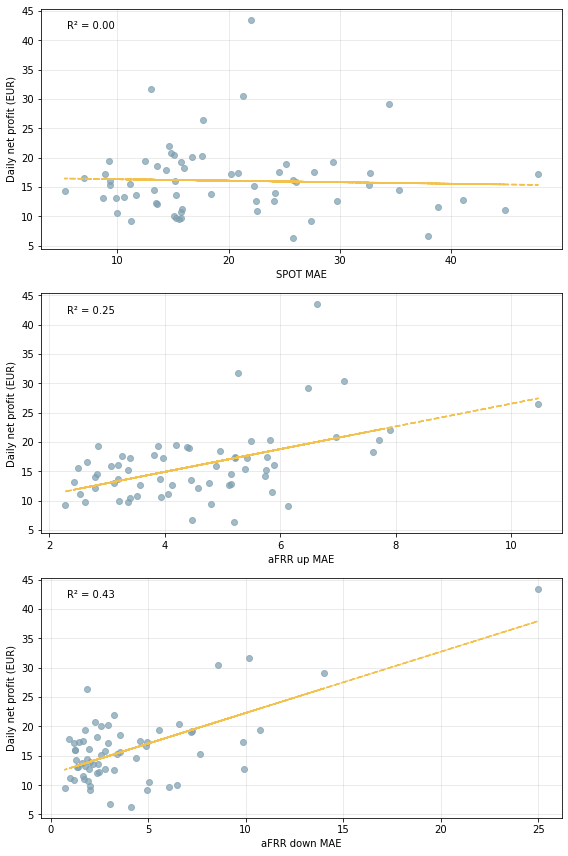

In [35]:
from sklearn.metrics import r2_score

df1 = pd.read_csv("../data/backtesting_results/files_revenues_qh_cycled/revenues_qh_strategies_horizon_2_SRS_cycled_Ex-post.csv")
df2 = pd.read_csv("../data/backtesting_results/prediction_errors_horizon_32_days_SRS.csv"
                  )

df1['datetime'] = pd.to_datetime(df1['datetime'], utc=True)
df1['datetime'] = df1['datetime'].dt.tz_convert('Europe/Madrid')

df2['datetime'] = pd.to_datetime(df2['datetime'], utc=True)
df2['datetime'] = df2['datetime'].dt.tz_convert('Europe/Madrid')
mask = df2['BANDA_subir_days_since_start'] == 1
df_merged = pd.merge(
    df1,
    df2[mask],
    on=["datetime"],
    how="left"
)
df_merged['day'] = pd.to_datetime(df_merged['datetime']).dt.date

merged_cols = ["net_profit_EUR", 'SPOT_abs_error']
errors = [("SPOT_abs_error", "SPOT MAE")]
if 'banda_up_offered_MW' in df1.columns:
    merged_cols.extend(['BANDA_subir_abs_error', 'BANDA_bajar_abs_error'])
    errors.extend([("BANDA_subir_abs_error", "aFRR up MAE"), ("BANDA_bajar_abs_error", "aFRR down MAE")])
    fig, axes = plt.subplots(3, 1, figsize=(8, 12))
else: 
    fig, axes = plt.subplots(1,1)

grouped = df_merged.groupby("day")[merged_cols].mean()

if not isinstance(axes, (list, np.ndarray)):
    axes = [axes]

for ax, (err_col, err_label) in zip(axes, errors):

    ax.scatter(grouped[err_col].values, grouped["net_profit_EUR"].values, alpha=0.7, color="#7d9fb0")
    ax.set_xlabel(err_label)
    ax.set_ylabel("Daily net profit (EUR)")

    # Línea de regresión opcional
    m, b = np.polyfit(grouped[err_col].dropna(), grouped["net_profit_EUR"].dropna(), 1)
    ax.plot(grouped[err_col].values, m * grouped[err_col].values + b, color="#f2c14e", linestyle="--")

    ax.grid(alpha=0.3)

    # Calculate and display R-squared value
    r2 = r2_score(grouped["net_profit_EUR"].dropna(), m * grouped[err_col].dropna() + b)
    ax.text(0.05, 0.95, f"R² = {r2:.2f}", transform=ax.transAxes, verticalalignment='top')

plt.tight_layout()
plt.show()
